# Resultados Finais — Latent Fusion

Execução completa do backtest engine com todas as validações implementadas.

In [1]:
import sys, os, time
from pathlib import Path

_root = Path(os.getcwd())
while not ((_root / 'src').exists() and (_root / 'pyproject.toml').exists()) and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.backtest.engine import BacktestEngine, BacktestConfig, decompose_alpha_beta
from src.backtest.monte_carlo import monte_carlo_simulate, MonteCarloConfig
from src.backtest.optimizer import grid_search, walk_forward_optimize, WalkForwardConfig
from src.backtest.stress_test import run_stress_tests
from src.backtest.visualization import BG, PANEL, GOLD, GREEN, RED, WHITE, CYAN
from src.strategy import SmaCrossStrategy, MeanReversionStrategy, RegimeRouterStrategy, S1Hard70Strategy, IntensityGatedStrategy
from src.features import compute_all, realized_volatility, volatility_regime_labels, hawkes_intensity

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)


## 1. Dados — Portfólio Real

Portfólio equal-weight de 49 ações US com 3.849 dias históricos (2009–2025).
A série de preços é construída a partir dos retornos reais cross-sectionais — split temporal 70/30.
Todas as estratégias correm sobre as mesmas condições de mercado.

In [2]:
cached = pd.read_pickle(_root / 'cache/data/top50_prepared_data.pkl')
ret_df      = cached['ret_df']
intensity_df = cached['intensity_df']
known_ret   = cached['known_ret']
regime      = cached['regime']
mask        = cached['mask']
split_emb   = 2694

bh_w   = mask.div(mask.sum(axis=1).replace(0.0, float('nan')), axis=0).fillna(0.0)
bh_ret = (bh_w * ret_df.fillna(0.0)).sum(axis=1)

price_port  = (1 + bh_ret).cumprod() * 100.0
vol_port    = price_port * (1 + np.random.default_rng(0).standard_normal(len(price_port)) * 0.001)

df_port = pd.DataFrame({
    'timestamp': ret_df.index,
    'close': price_port.values,
    'open':  price_port.values * (1 + np.random.default_rng(1).standard_normal(len(price_port)) * 0.002),
    'high':  price_port.values * (1 + np.abs(np.random.default_rng(2).standard_normal(len(price_port))) * 0.003),
    'low':   price_port.values * (1 - np.abs(np.random.default_rng(3).standard_normal(len(price_port))) * 0.003),
})

split = split_emb
df_train, df_test = df_port.iloc[:split].copy(), df_port.iloc[split:].copy()
df = df_port

config = BacktestConfig(initial_cash=10_000, fee_bps=4, slippage_bps=1, periods_per_year=252)
engine = BacktestEngine(config)
_images = _root / 'images'
_images.mkdir(exist_ok=True)

pd.DataFrame({
    'split': ['train', 'test'],
    'days': [len(df_train), len(df_test)],
    'from': [str(df_train['timestamp'].iloc[0].date()), str(df_test['timestamp'].iloc[0].date())],
    'to':   [str(df_train['timestamp'].iloc[-1].date()), str(df_test['timestamp'].iloc[-1].date())],
    'bh_return_pct': [
        (df_train['close'].iloc[-1]/df_train['close'].iloc[0]-1)*100,
        (df_test['close'].iloc[-1]/df_test['close'].iloc[0]-1)*100,
    ]
})


,split,days,from,to,bh_return_pct
0,train,2694,2009-04-14,2020-07-08,319.138723
1,test,1155,2020-07-09,2025-03-27,91.335798


## 2. Estratégias Determinísticas vs Buy & Hold

Todas as estratégias disponíveis rodando no portfólio de 49 ações (período de teste).
Comparação direta contra buy & hold com decomposição alpha/beta.

In [3]:
strategies = {
    'SMA 20/100': SmaCrossStrategy(20, 100),
    'SMA 10/50': SmaCrossStrategy(10, 50),
    'Mean Reversion': MeanReversionStrategy(lookback=50, z_entry=1.5, z_exit=0.3),
    'Regime Router': RegimeRouterStrategy(vol_window=20, regime_percentile=50, mom_window=5),
    'S1 Hard70': S1Hard70Strategy(vol_window=20, regime_percentile=50, mom_window=3, gate_percentile=70, intensity_lookback=252),
    'Intensity Gated': IntensityGatedStrategy(vol_window=20, gate_percentile=70, gate_type='hard'),
}

results = {}
rows = []
for name, strat in strategies.items():
    r = engine.run(df_test, strat)
    results[name] = r
    m = r.metrics
    rows.append({
        'strategy': name,
        'return_pct': round(m['total_return_pct'], 1),
        'bh_return_pct': round(m['bh_return_pct'], 1),
        'excess_pct': round(m['excess_return_pct'], 1),
        'sharpe': round(m['sharpe'], 2),
        'sortino': round(m['sortino'], 2),
        'max_dd_pct': round(m['max_drawdown_pct'], 1),
        'cagr_pct': round(m['cagr_pct'], 1),
        'calmar': round(m['calmar'], 2),
        'alpha_pct': round(m['alpha_pct'], 1),
        'beta': round(m['beta'], 2),
        'r_squared': round(m['r_squared'], 2),
        'trades': int(m['trade_count']),
        'win_pct': round(m['win_rate_pct'], 1),
        'profit_factor': round(m['profit_factor'], 2),
    })

pd.DataFrame(rows).set_index('strategy')


,return_pct,bh_return_pct,excess_pct,sharpe,sortino,max_dd_pct,cagr_pct,calmar,alpha_pct,beta,r_squared,trades,win_pct,profit_factor
strategy,,,,,,,,,,,,,,
SMA 20/100,19.6,91.3,-71.7,0.40,0.48,-22.9,4.0,0.17,-3.8,0.54,0.54,46,0.0,0.0
SMA 10/50,4.9,91.3,-86.4,0.15,0.17,-28.5,1.0,0.04,-6.5,0.53,0.53,84,0.0,0.0
Mean Reversion,6.3,91.3,-85.1,0.17,0.22,-22.4,1.3,0.06,3.5,-0.10,0.01,632,0.0,0.0
Regime Router,-29.3,91.3,-120.6,-0.41,-0.63,-39.0,-7.3,-0.19,-5.4,-0.06,0.00,1020,0.0,0.0
S1 Hard70,-13.2,91.3,-104.5,-0.25,-0.19,-24.6,-3.0,-0.12,-2.3,-0.01,0.00,329,0.0,0.0
Intensity Gated,-16.8,91.3,-108.1,-0.31,-0.26,-29.5,-3.9,-0.13,-3.2,-0.01,0.00,340,0.0,0.0


## 2b. Estratégias com Embeddings de Texto

S1 Hard70 com embeddings de texto (SentenceTransformer all-MiniLM-L6-v2, 50 ações US).
Mesmo portfólio e benchmark que as estratégias determinísticas.

In [4]:
cached = pd.read_pickle(_root / 'cache/data/top50_prepared_data.pkl')
ret_df = cached['ret_df']
intensity_df = cached['intensity_df']
known_ret = cached['known_ret']
regime = cached['regime']
mask = cached['mask']
split_emb = 2694

pd.DataFrame({
    '': ['ret_df', 'intensity_df', 'known_ret', 'tickers', 'dates', 'train_split'],
    'value': [str(ret_df.shape), str(intensity_df.shape), str(known_ret.shape),
              ret_df.shape[1], ret_df.shape[0], split_emb]
})


,,value
0,ret_df,"(3849, 49)"
1,intensity_df,"(3849, 49)"
2,known_ret,"(3849, 49)"
3,tickers,49
4,dates,3849
5,train_split,2694


In [5]:
int_rank = intensity_df.rank(axis=1, pct=True)
hard70 = (int_rank >= 0.70).astype(float)
reg_mat = pd.DataFrame(np.repeat(regime.values[:, None], ret_df.shape[1], axis=1), index=ret_df.index, columns=ret_df.columns)
rev1 = -np.sign(known_ret).fillna(0.0)
mom3 = np.sign(known_ret.rolling(3, min_periods=2).mean()).fillna(0.0)
raw_text = hard70 * (reg_mat * rev1 + (1.0 - reg_mat) * mom3)

def build_tilt(ra):
    x = (ra * mask).fillna(0.0)
    x = x.sub(x.mean(axis=1), axis=0)
    x = x.div(x.abs().sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
    return x

tilt_text = build_tilt(raw_text)
bh_w = mask.div(mask.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
bh_ret_emb = (bh_w * ret_df.fillna(0.0)).sum(axis=1)
mkt_trend = known_ret.mean(axis=1).rolling(20, min_periods=10).mean().fillna(0.0)
exposure = pd.Series(np.where(mkt_trend > 0, 1.30, 1.00), index=ret_df.index)
w_text = (bh_w + 0.05 * tilt_text).clip(lower=0.0)
w_text = w_text.div(w_text.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
base_text = (w_text * ret_df.fillna(0.0)).sum(axis=1)
sr_text = exposure * base_text

df_text = pd.DataFrame({'timestamp': sr_text.index, 'close': (1 + sr_text).cumprod() * config.initial_cash})
df_bh_emb = pd.DataFrame({'timestamp': bh_ret_emb.index, 'close': (1 + bh_ret_emb).cumprod() * config.initial_cash})

r_text = BacktestEngine(config).run(df_text.iloc[split_emb:], SmaCrossStrategy(20, 100))
r_text.metrics['total_return_pct'] = (sr_text.iloc[split_emb:].add(1).prod() - 1) * 100
r_text.metrics['bh_return_pct'] = (bh_ret_emb.iloc[split_emb:].add(1).prod() - 1) * 100
r_text.metrics['excess_return_pct'] = r_text.metrics['total_return_pct'] - r_text.metrics['bh_return_pct']
ab_text = decompose_alpha_beta(sr_text.iloc[split_emb:], bh_ret_emb.iloc[split_emb:], 252)
for k, v in ab_text.items():
    r_text.metrics[k] = v

pd.DataFrame({
    'Metric': ['Test Return', 'BH Return', 'Excess', 'Sharpe', 'Sortino', 'Max DD', 'Alpha (ann)', 'Beta', 'R2', 'Trades'],
    'Value': [f'{r_text.metrics["total_return_pct"]:+.2f}%', f'{r_text.metrics["bh_return_pct"]:+.2f}%',
              f'{r_text.metrics["excess_return_pct"]:+.2f}%', f'{r_text.metrics["sharpe"]:.3f}',
              f'{r_text.metrics["sortino"]:.3f}', f'{r_text.metrics["max_drawdown_pct"]:.1f}%',
              f'{r_text.metrics["alpha_pct"]:+.2f}%', f'{r_text.metrics["beta"]:.3f}',
              f'{r_text.metrics["r_squared"]:.3f}', int(r_text.metrics["trade_count"])]
})


,Metric,Value
0,Test Return,+122.39%
1,BH Return,+94.26%
2,Excess,+28.12%
3,Sharpe,0.447
4,Sortino,0.546
5,Max DD,-22.7%
6,Alpha (ann),+0.91%
7,Beta,1.158
8,R2,0.983
9,Trades,50


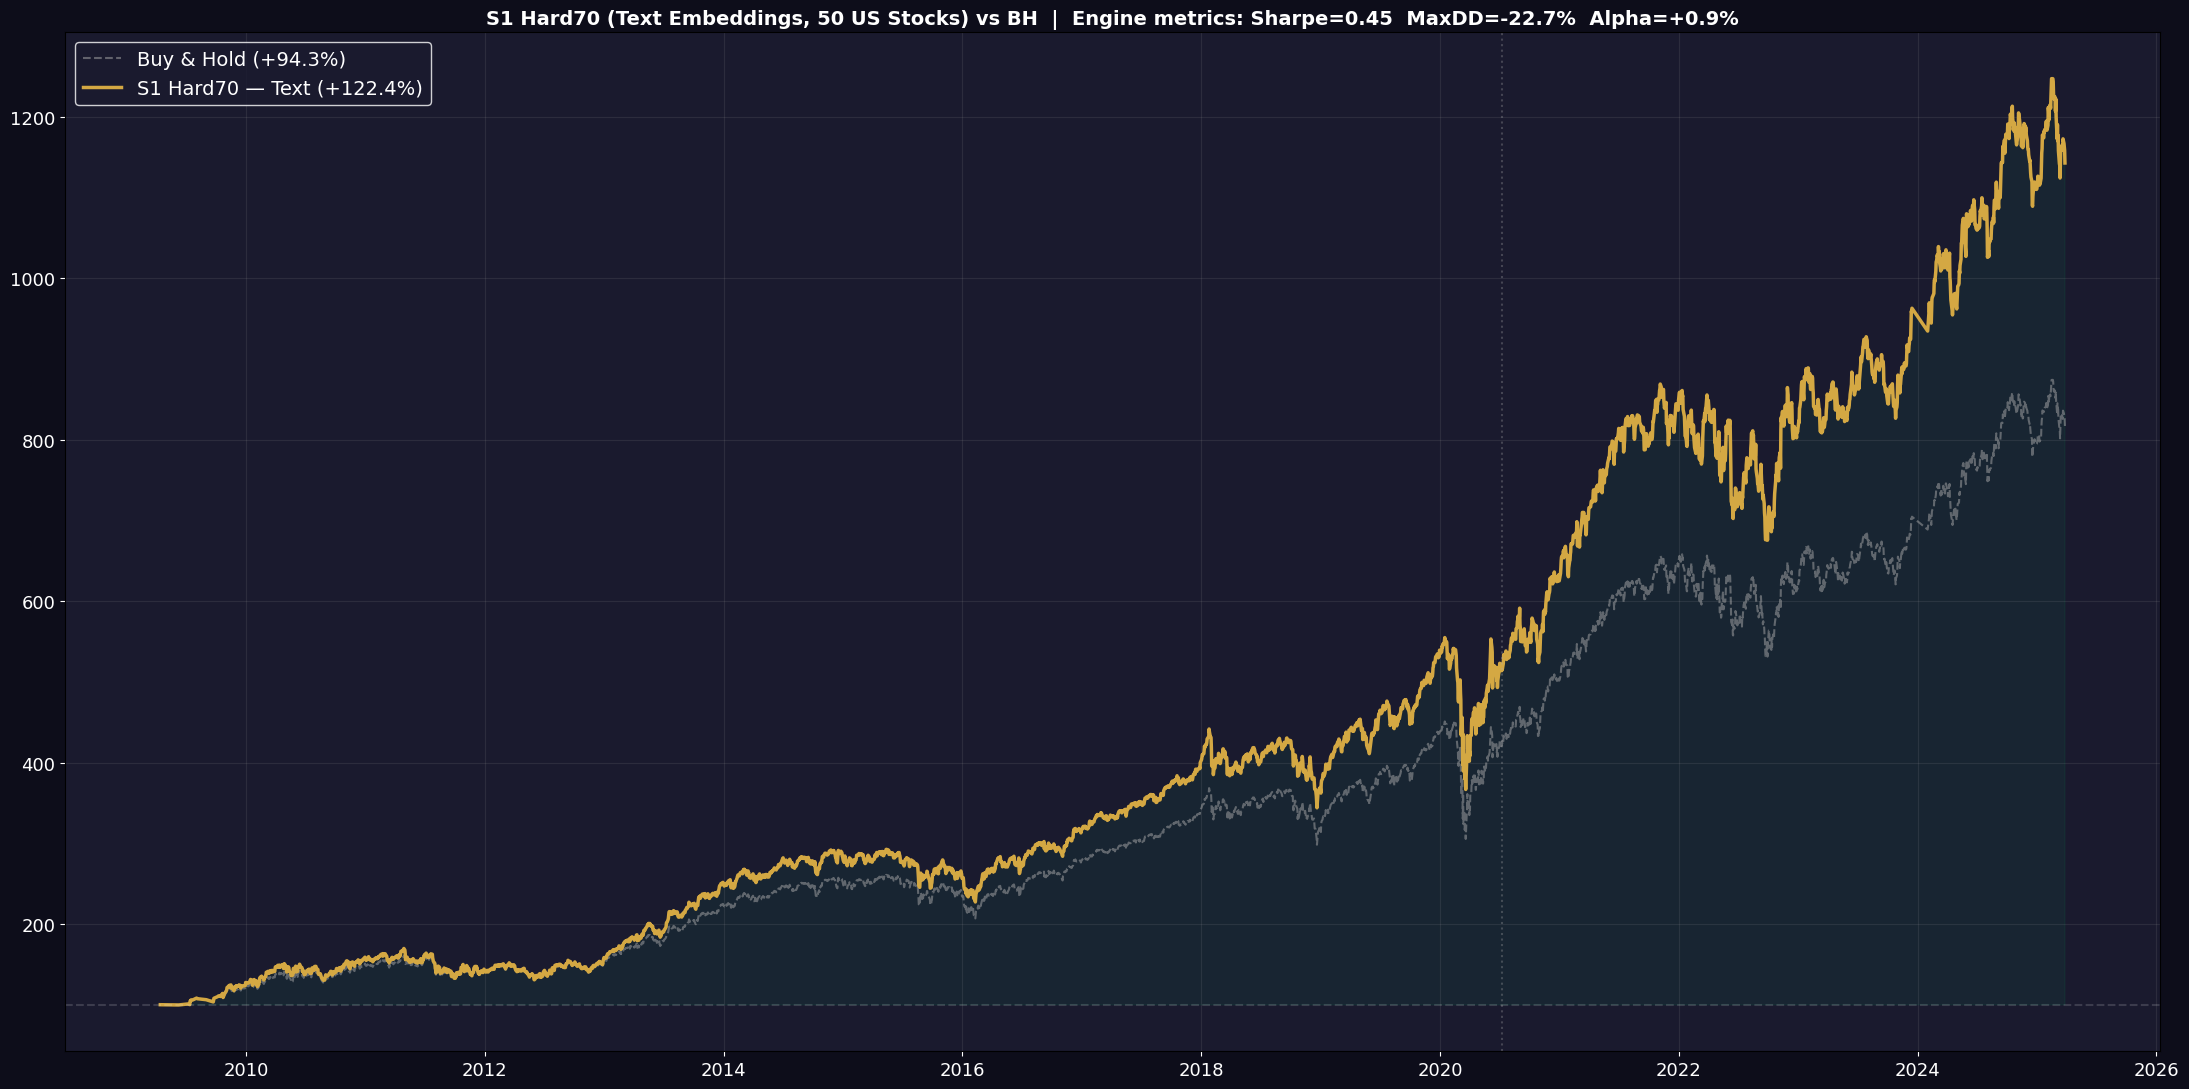

In [6]:
eq_text_emb = (1 + sr_text).cumprod() * 100
eq_bh_emb = (1 + bh_ret_emb).cumprod() * 100

fig, ax = plt.subplots(figsize=(22, 11))
fig.patch.set_facecolor(BG)
ax.plot(eq_bh_emb.index, eq_bh_emb.values, color=WHITE, lw=1.5, ls='--', alpha=0.5, label=f'Buy & Hold ({r_text.metrics["bh_return_pct"]:+.1f}%)')
ax.plot(eq_text_emb.index, eq_text_emb.values, color=GOLD, lw=2.5, label=f'S1 Hard70 — Text ({r_text.metrics["total_return_pct"]:+.1f}%)')
ax.axvline(ret_df.index[split_emb], color=WHITE, ls=':', alpha=0.3)
ax.fill_between(eq_text_emb.index, eq_text_emb.values, 100, where=eq_text_emb.values >= 100, color=GREEN, alpha=0.06)
ax.fill_between(eq_text_emb.index, eq_text_emb.values, 100, where=eq_text_emb.values < 100, color=RED, alpha=0.06)
ax.axhline(100, color='white', ls='--', alpha=0.15)
ax.set_title(f'S1 Hard70 (Text Embeddings, 50 US Stocks) vs BH  |  Engine metrics: Sharpe={r_text.metrics["sharpe"]:.2f}  MaxDD={r_text.metrics["max_drawdown_pct"]:.1f}%  Alpha={r_text.metrics["alpha_pct"]:+.1f}%', color='white', fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)
ax.tick_params(colors='white', labelsize=13)
ax.grid(True, alpha=0.12)
ax.legend(fontsize=14, facecolor=PANEL, edgecolor='white', labelcolor='white', loc='upper left')
fig.tight_layout()
fig.savefig(_images / 'final_embedding_text_vs_bh.png', dpi=300, facecolor=BG, edgecolor='none', bbox_inches='tight')
plt.show()


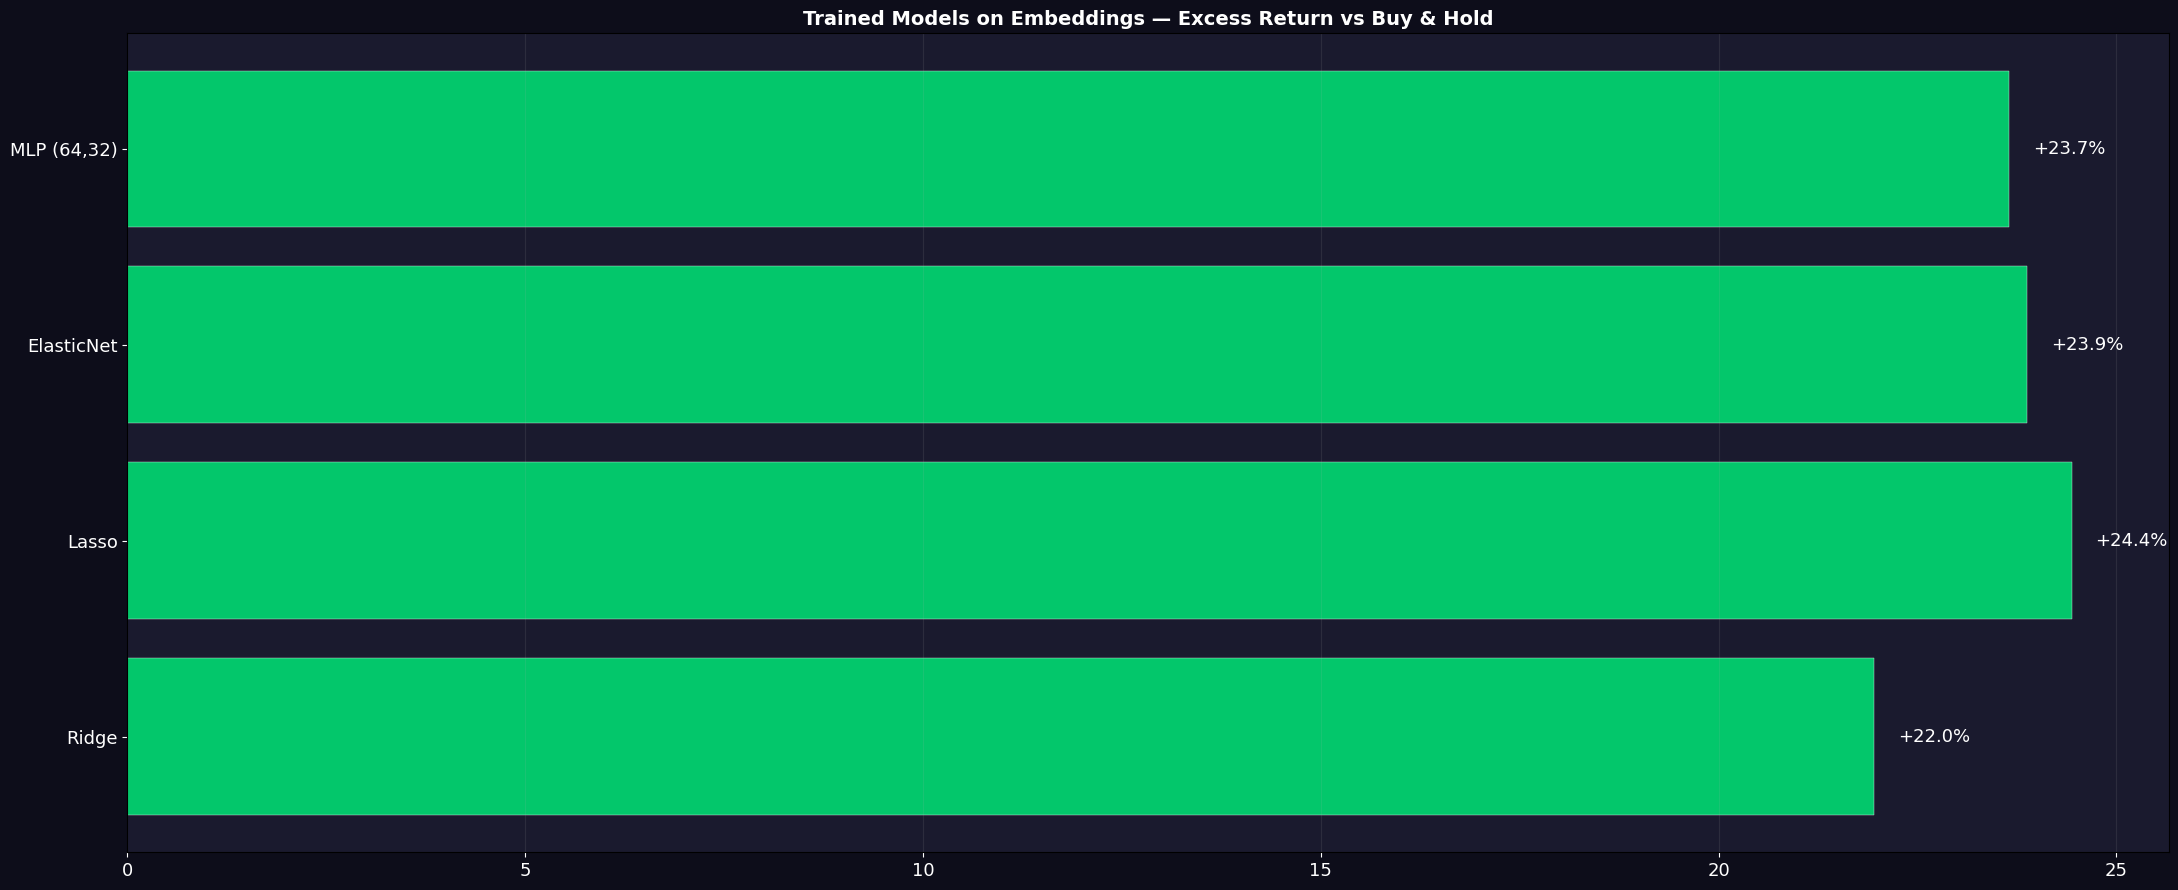

,model,train_corr,fit_time_s,test_return_pct,bh_return_pct,excess_pct,sharpe,bh_sharpe,alpha_pct,beta,r2
0,Ridge,0.028618,0.031880,116.221521,94.264426,21.957094,0.999746,0.99418,0.276462,1.159755,0.983015
1,Lasso,0.015383,0.039824,118.702649,94.264426,24.438223,1.019164,0.99418,0.570702,1.156189,0.983386
2,ElasticNet,0.016128,0.052413,118.142279,94.264426,23.877852,1.015380,0.99418,0.512786,1.156342,0.983355
3,"MLP (64,32)",0.112172,135.250163,117.915679,94.264426,23.651252,1.015017,0.99418,0.509410,1.154887,0.983027


In [7]:
model_results = pd.read_csv(_root / 'src/strategy/trained/images/model_comparison.csv')

fig, ax = plt.subplots(figsize=(22, 9))
fig.patch.set_facecolor(BG)
y_pos = np.arange(len(model_results))
rets = model_results['excess_pct'].values
colors = [GREEN if v > 0 else RED for v in rets]
ax.barh(y_pos, rets, color=colors, alpha=0.85, edgecolor='white', lw=0.3)
ax.set_yticks(y_pos)
ax.set_yticklabels(model_results['model'], color='white', fontsize=14)
ax.axvline(0, color='white', lw=0.5)
for i, v in enumerate(rets):
    ax.text(v + (0.3 if v >= 0 else -3), i, f'{v:+.1f}%', va='center', color='white', fontsize=13)
ax.set_title('Trained Models on Embeddings — Excess Return vs Buy & Hold', color='white', fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)
ax.tick_params(colors='white', labelsize=13)
ax.grid(True, alpha=0.12, axis='x')
fig.tight_layout()
fig.savefig(_images / 'final_trained_models_excess.png', dpi=300, facecolor=BG, edgecolor='none', bbox_inches='tight')
plt.show()

model_results


In [8]:
strat_num = IntensityGatedStrategy(vol_window=20, gate_percentile=70, gate_type='hard')
r_num = BacktestEngine(config).run(df_test, strat_num)
m_num = r_num.metrics

pd.DataFrame({
    'Strategy': ['Text Embedding (S1 Hard70, 50 stocks)', 'Numerical (Intensity Gated, portfolio)', 'Buy & Hold'],
    'Return': [f"{r_text.metrics['total_return_pct']:+.1f}%", f'{m_num["total_return_pct"]:+.1f}%', f'{m_num["bh_return_pct"]:+.1f}%'],
    'Sharpe': [f"{r_text.metrics['sharpe']:.3f}", f'{m_num["sharpe"]:.3f}', f'{m_num.get("sharpe",0):.3f}'],
    'Alpha':  [f'{ab_text["alpha_pct"]:+.2f}%', f'{m_num["alpha_pct"]:+.2f}%', '—'],
})


,Strategy,Return,Sharpe,Alpha
0,"Text Embedding (S1 Hard70, 50 stocks)",+122.4%,0.447,+0.91%
1,"Numerical (Intensity Gated, portfolio)",-16.8%,-0.311,-3.18%
2,Buy & Hold,+91.3%,-0.311,—


## 2c. Embeddings Numéricos — MOMENT

MOMENT-1-large (1024-dim) sobre janelas de 30 dias. Mesmo pipeline: drift -> Hawkes -> hard70 gate -> regime router. Cache em cache/moment/.

In [9]:
# Build MOMENT embedding portfolio (sr_moment, bh_ret_m, sp_m, dates_m)
# Loads from cache/moment/ — no GPU needed, pure numpy.
_meta_m = pd.read_csv(_root / 'cache/moment/top50_moment_metadata.csv')
_emb_m  = np.load(_root / 'cache/moment/top50_moment_embeddings.npy')
_meta_m['date'] = pd.to_datetime(_meta_m['date'])
_meta_m['emb_idx'] = np.arange(len(_meta_m))

_tickers_m = list(set(_meta_m['ticker'].unique()) & set(ret_df.columns))

# per-ticker daily embedding drift (L2 of consecutive mean embeddings)
_drift_dict = {}
for _tk in _tickers_m:
    _rows = _meta_m[_meta_m['ticker'] == _tk].sort_values('date')
    if len(_rows) < 2: continue
    _e = _emb_m[_rows['emb_idx'].values]
    _d = np.linalg.norm(np.diff(_e, axis=0), axis=1)
    _drift_dict[_tk] = pd.Series(_d, index=pd.to_datetime(_rows['date'].values[1:]))
_drift_m = pd.DataFrame(_drift_dict).sort_index()

def _hawkes_1d(s, alpha=0.8, beta=0.2):
    p95 = s.quantile(0.95)
    ev  = (s >= p95).astype(float).values
    lam = np.zeros(len(ev)); v = 0.0
    for i, e in enumerate(ev):
        v = np.exp(-beta) * v + alpha * e
        lam[i] = v
    return pd.Series(lam, index=s.index)

_intensity_m = _drift_m.apply(_hawkes_1d, axis=0)

# align with ret_df (already loaded in cell 7)
_common_m  = _intensity_m.index.intersection(ret_df.index)
_int_m     = _intensity_m.loc[_common_m, _tickers_m]
_ret_m     = ret_df.loc[_common_m, _tickers_m].fillna(0.0)
_mask_m    = mask.loc[_common_m, _tickers_m].fillna(0.0)

# hard70 gate + regime router
_rank_m    = _int_m.rank(axis=1, pct=True)
_gate_m    = (_rank_m >= 0.70).astype(float)
_vol_m     = _ret_m.rolling(20, min_periods=5).std()
_reg_m     = (_vol_m.mean(axis=1) > _vol_m.mean(axis=1).rolling(20).median()).astype(float).fillna(0.0)
_regmat_m  = pd.DataFrame(np.repeat(_reg_m.values[:,None], len(_tickers_m), axis=1),
                           index=_common_m, columns=_tickers_m)
_kr_m      = ret_df.loc[_common_m, _tickers_m].shift(1).fillna(0.0)
_rev_m     = -np.sign(_kr_m)
_mom_m     = np.sign(_kr_m.rolling(3, min_periods=2).mean()).fillna(0.0)
_raw_m     = _gate_m * (_regmat_m * _rev_m + (1.0 - _regmat_m) * _mom_m)

def _build_tilt_m(ra):
    x = (ra * _mask_m).fillna(0.0)
    x = x.sub(x.mean(axis=1), axis=0)
    return x.div(x.abs().sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

_bh_w_m    = _mask_m.div(_mask_m.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
bh_ret_m   = (_bh_w_m * _ret_m).sum(axis=1)
_mkt_m     = _kr_m.mean(axis=1).rolling(20, min_periods=10).mean().fillna(0.0)
_exp_m     = pd.Series(np.where(_mkt_m > 0, 1.30, 1.00), index=_common_m)
_tilt_m    = _build_tilt_m(_raw_m)
_w_m       = (_bh_w_m + 0.05 * _tilt_m).clip(lower=0.0)
_w_m       = _w_m.div(_w_m.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
sr_moment  = _exp_m * (_w_m * _ret_m).sum(axis=1)

sp_m    = int(len(_common_m) * 0.70)
dates_m = _common_m

pd.DataFrame({
    'Metric': ['Dates', 'Tickers', 'Test return', 'BH return', 'Excess', 'Test from'],
    'Value':  [str(len(_common_m)), str(len(_tickers_m)),
               f'{(sr_moment.iloc[sp_m:].add(1).prod()-1)*100:+.2f}%',
               f'{(bh_ret_m.iloc[sp_m:].add(1).prod()-1)*100:+.2f}%',
               f'{((sr_moment.iloc[sp_m:].add(1).prod())/(bh_ret_m.iloc[sp_m:].add(1).prod())-1)*100:+.2f}%',
               str(dates_m[sp_m].date())]
})


,Metric,Value
0,Dates,1280
1,Tickers,49
2,Test return,+26.03%
3,BH return,+20.97%
4,Excess,+4.18%
5,Test from,2023-08-02


In [10]:
# Run MOMENT portfolio through backtest engine
df_moment = pd.DataFrame({'timestamp': sr_moment.index, 'close': (1 + sr_moment).cumprod() * config.initial_cash})
df_bh_m = pd.DataFrame({'timestamp': bh_ret_m.index, 'close': (1 + bh_ret_m).cumprod() * config.initial_cash})

r_moment = BacktestEngine(config).run(df_moment.iloc[sp_m:], SmaCrossStrategy(20, 100))
r_moment.metrics['total_return_pct'] = (sr_moment.iloc[sp_m:].add(1).prod() - 1) * 100
r_moment.metrics['bh_return_pct'] = (bh_ret_m.iloc[sp_m:].add(1).prod() - 1) * 100
r_moment.metrics['excess_return_pct'] = r_moment.metrics['total_return_pct'] - r_moment.metrics['bh_return_pct']
ab_m = decompose_alpha_beta(sr_moment.iloc[sp_m:], bh_ret_m.iloc[sp_m:], 252)
for k, v in ab_m.items():
    r_moment.metrics[k] = v

pd.DataFrame({
    'Metric': ['Test Return', 'BH Return', 'Excess', 'Sharpe', 'Sortino', 'Max DD', 'Alpha (ann)', 'Beta', 'R2'],
    'Value': [f'{r_moment.metrics["total_return_pct"]:+.2f}%', f'{r_moment.metrics["bh_return_pct"]:+.2f}%',
              f'{r_moment.metrics["excess_return_pct"]:+.2f}%', f'{r_moment.metrics["sharpe"]:.3f}',
              f'{r_moment.metrics["sortino"]:.3f}', f'{r_moment.metrics["max_drawdown_pct"]:.1f}%',
              f'{r_moment.metrics["alpha_pct"]:+.2f}%', f'{r_moment.metrics["beta"]:.3f}',
              f'{r_moment.metrics["r_squared"]:.3f}']
})


,Metric,Value
0,Test Return,+26.03%
1,BH Return,+20.97%
2,Excess,+5.05%
3,Sharpe,0.705
4,Sortino,0.873
5,Max DD,-14.7%
6,Alpha (ann),+0.78%
7,Beta,1.166
8,R2,0.983


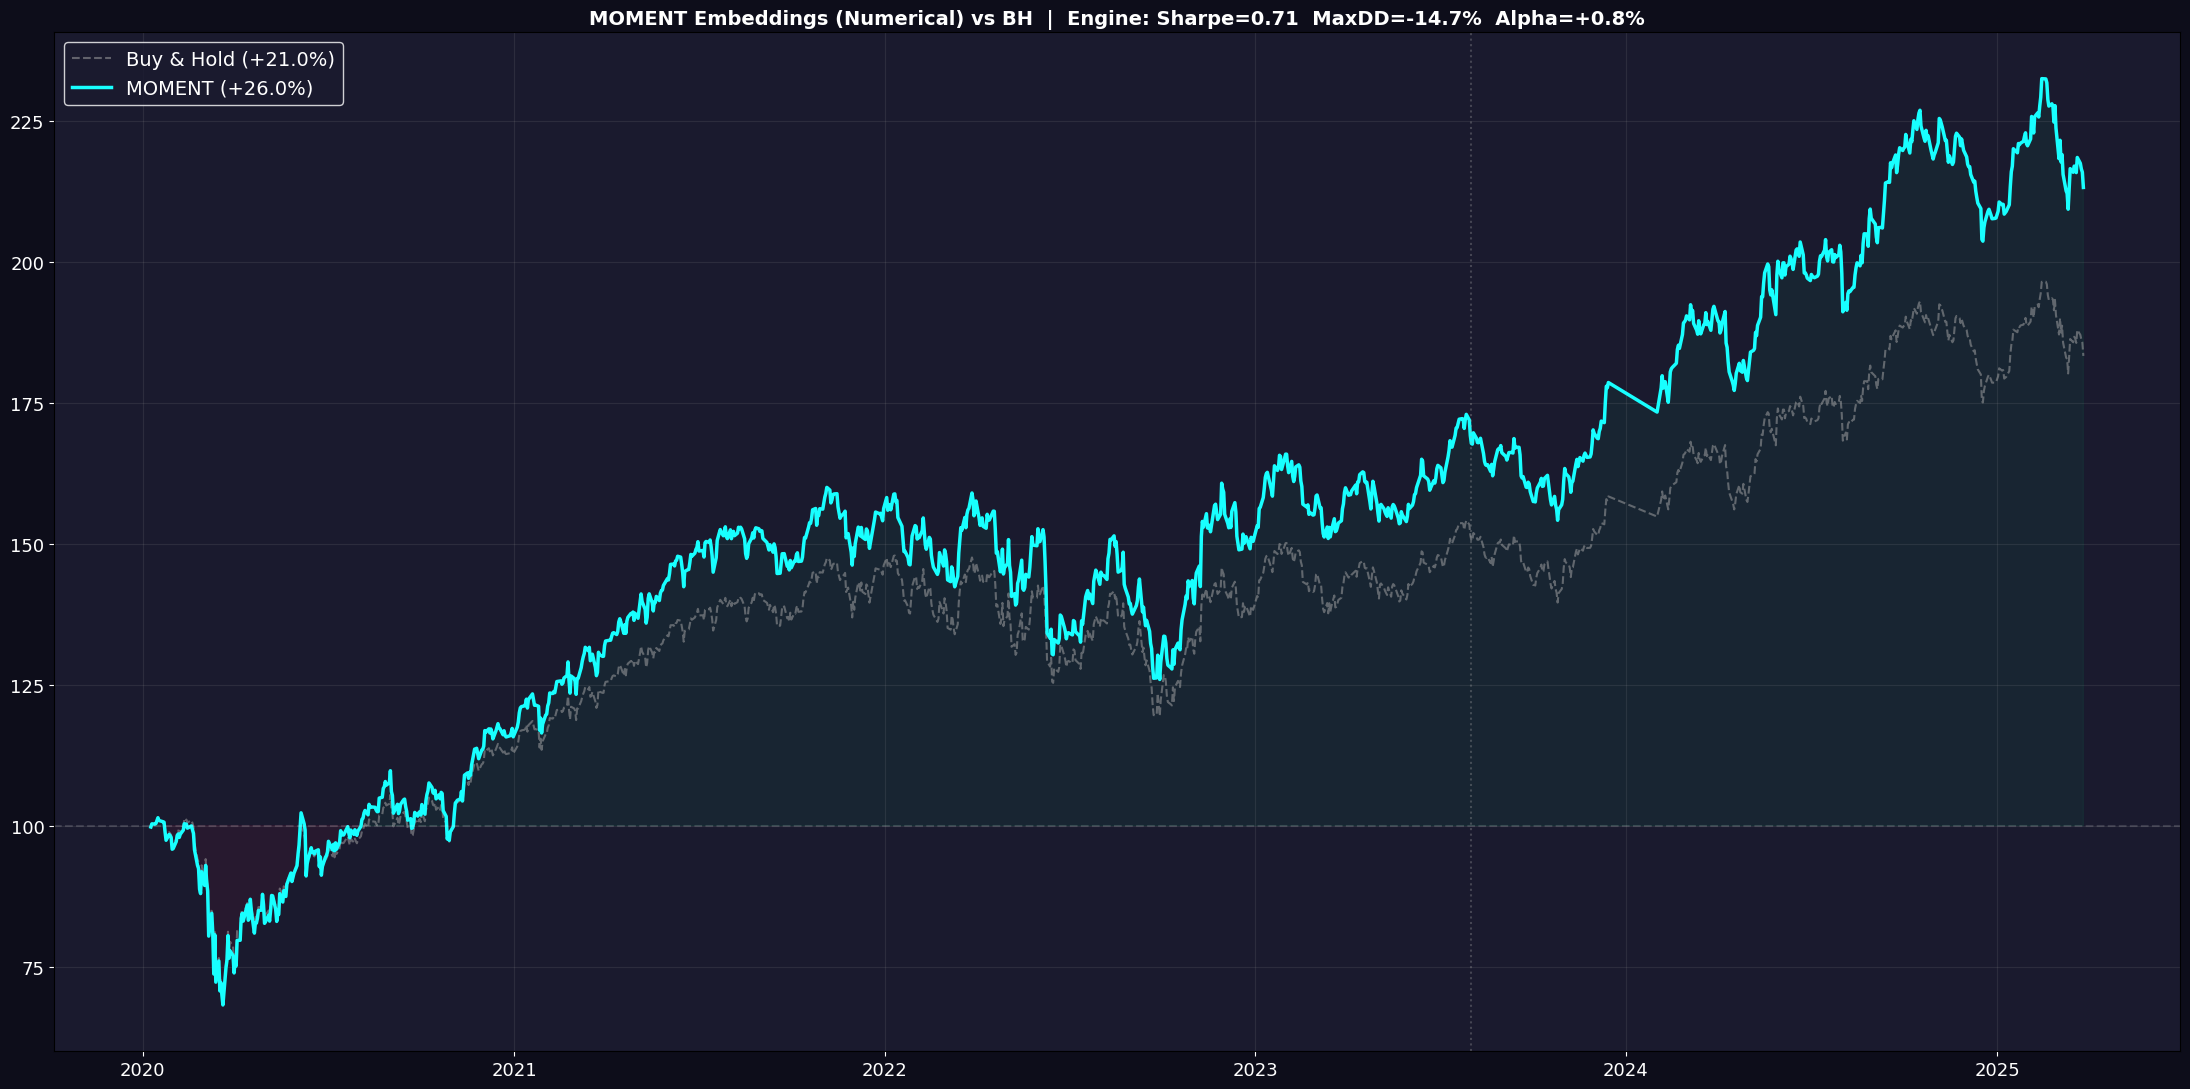

In [11]:
eq_moment = (1 + sr_moment).cumprod() * 100
eq_bh_m = (1 + bh_ret_m).cumprod() * 100

fig, ax = plt.subplots(figsize=(22, 11))
fig.patch.set_facecolor(BG)
ax.plot(eq_bh_m.index, eq_bh_m.values, color=WHITE, lw=1.5, ls='--', alpha=0.5, label=f'Buy & Hold ({r_moment.metrics["bh_return_pct"]:+.1f}%)')
ax.plot(eq_moment.index, eq_moment.values, color=CYAN, lw=2.5, label=f'MOMENT ({r_moment.metrics["total_return_pct"]:+.1f}%)')
ax.axvline(dates_m[sp_m], color=WHITE, ls=':', alpha=0.3)
ax.fill_between(eq_moment.index, eq_moment.values, 100, where=eq_moment.values >= 100, color=GREEN, alpha=0.06)
ax.fill_between(eq_moment.index, eq_moment.values, 100, where=eq_moment.values < 100, color=RED, alpha=0.06)
ax.axhline(100, color='white', ls='--', alpha=0.15)
ax.set_title(f'MOMENT Embeddings (Numerical) vs BH  |  Engine: Sharpe={r_moment.metrics["sharpe"]:.2f}  MaxDD={r_moment.metrics["max_drawdown_pct"]:.1f}%  Alpha={r_moment.metrics["alpha_pct"]:+.1f}%', color='white', fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)
ax.tick_params(colors='white', labelsize=13)
ax.grid(True, alpha=0.12)
ax.legend(fontsize=14, facecolor=PANEL, edgecolor='white', labelcolor='white', loc='upper left')
fig.tight_layout()
fig.savefig(_images / 'final_embedding_moment_vs_bh.png', dpi=300, facecolor=BG, edgecolor='none', bbox_inches='tight')
plt.show()


## 3. Grid Search — Portfólio Real

Varredura exaustiva de hiperparâmetros no conjunto de treino do portfólio.
Heatmap com contraste automático e colorbar.

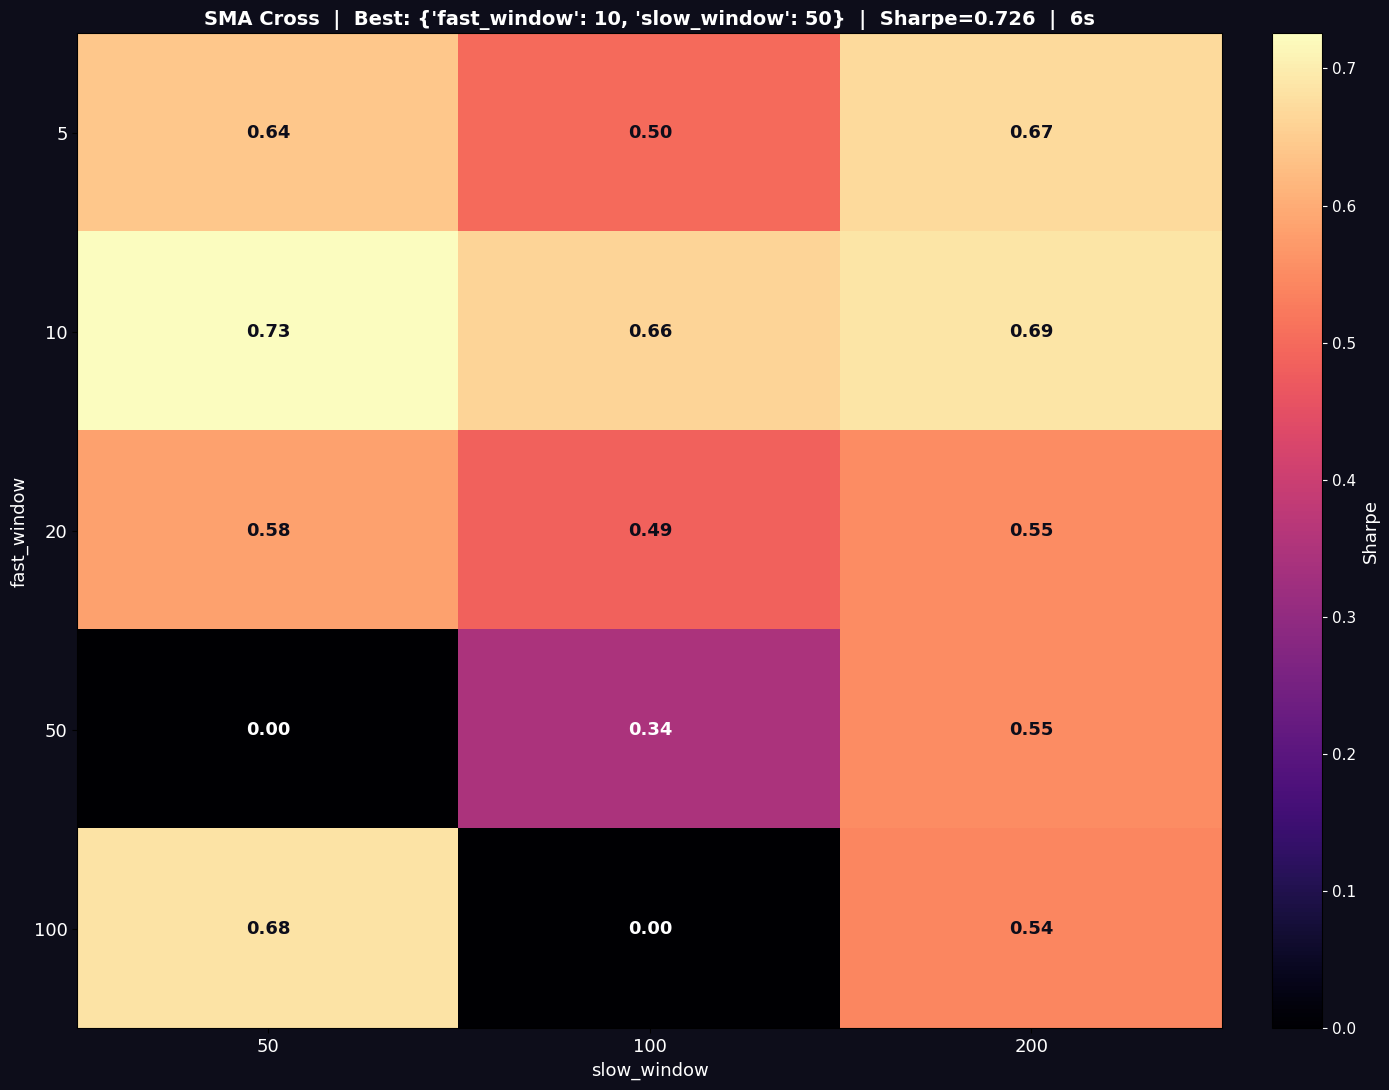

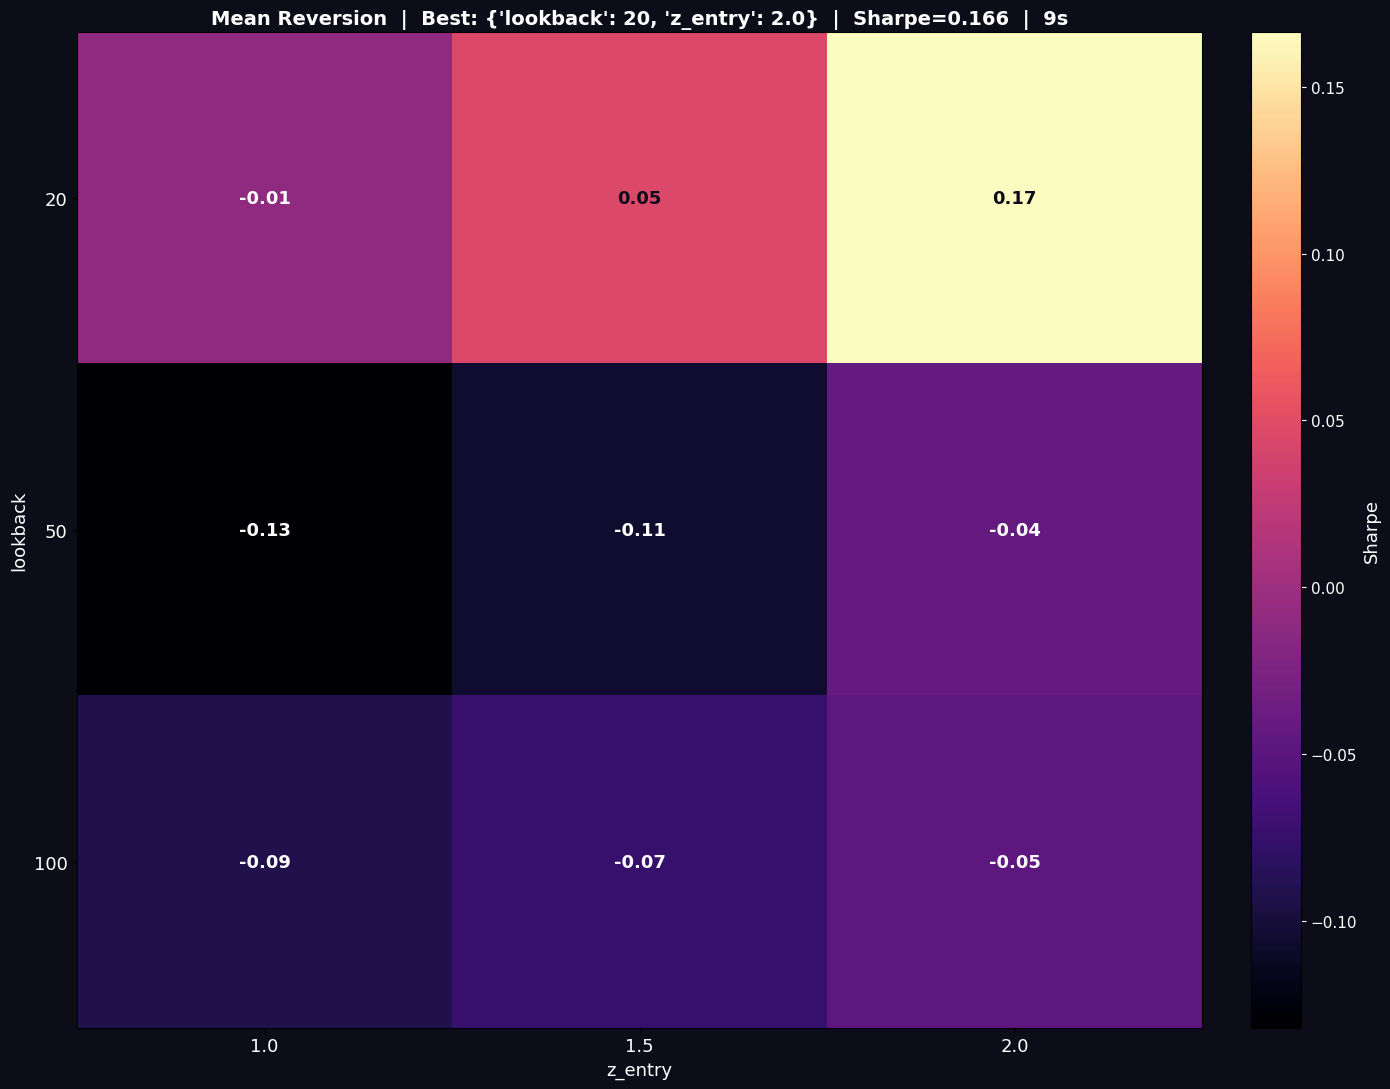

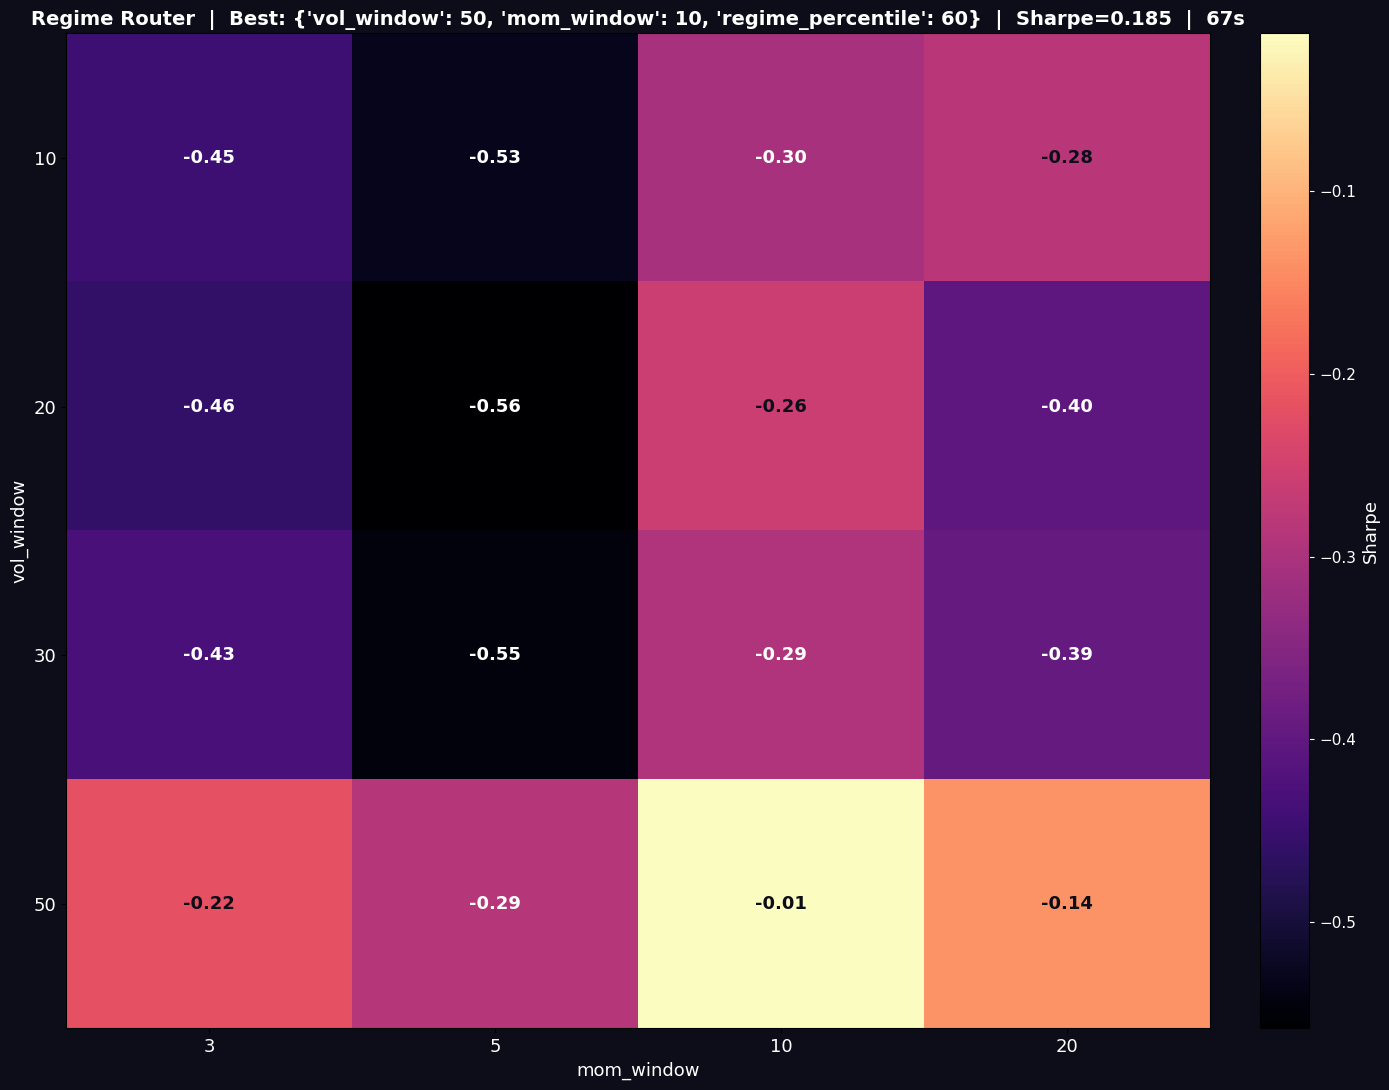

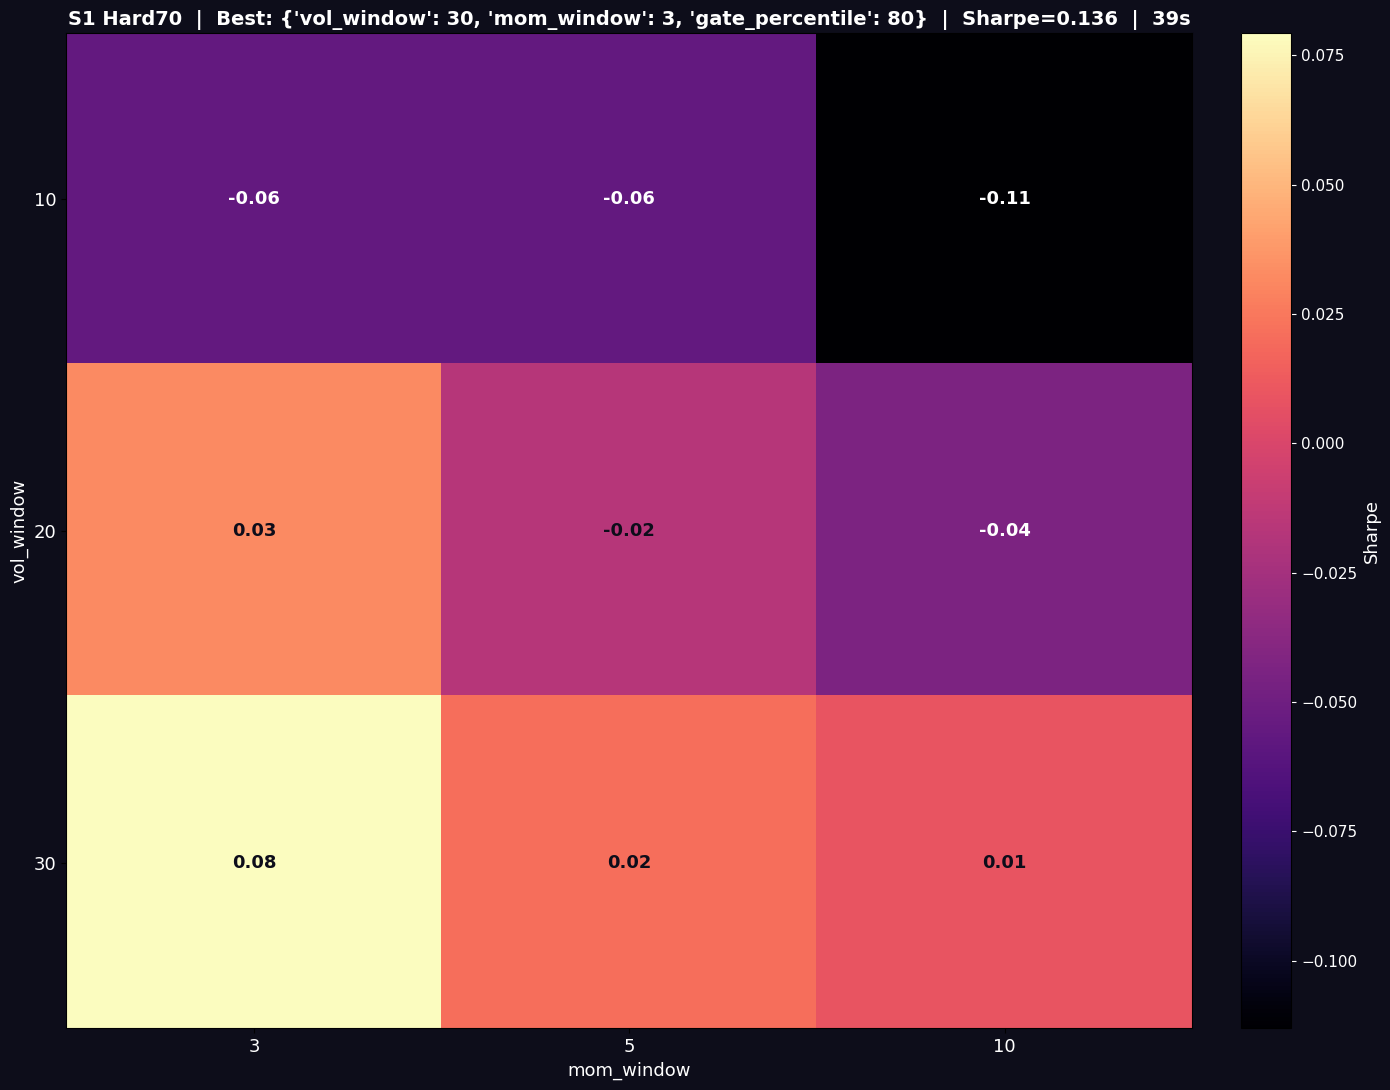

In [12]:
strategy_grids = {
    'SMA Cross': (SmaCrossStrategy, {'fast_window': [5, 10, 20, 50, 100], 'slow_window': [50, 100, 200]}),
    'Mean Reversion': (MeanReversionStrategy, {'lookback': [20, 50, 100], 'z_entry': [1.0, 1.5, 2.0]}),
    'Regime Router': (RegimeRouterStrategy, {'vol_window': [10, 20, 30, 50], 'mom_window': [3, 5, 10, 20], 'regime_percentile': [40, 50, 60]}),
    'S1 Hard70': (S1Hard70Strategy, {'vol_window': [10, 20, 30], 'mom_window': [3, 5, 10], 'gate_percentile': [60, 70, 80]}),
}

heatmap_results = {}
for name, (cls, grid) in strategy_grids.items():
    t0 = time.time()
    gs = grid_search(df_train, cls, grid, config=config, metric='sharpe', verbose=False)
    heatmap_results[name] = gs
    
    keys = list(gs.best_params.keys())
    pivot = gs.all_results.pivot_table(values='_score', index=keys[0], columns=keys[1] if len(keys)>1 else keys[0], aggfunc='mean')
    vals = pivot.values
    vmin, vmax = vals.min(), vals.max()
    mid = (vmin + vmax) / 2
    
    fig, ax = plt.subplots(figsize=(14, 11))
    fig.patch.set_facecolor(BG)
    im = ax.imshow(vals, aspect='auto', cmap='magma', vmin=vmin, vmax=vmax)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = vals[i, j]
            clr = 'white' if val < mid else '#0d0d1a'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=clr, fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, color='white', fontsize=13)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color='white', fontsize=13)
    ax.set_title(f'{name}  |  Best: {gs.best_params}  |  Sharpe={gs.best_score:.3f}  |  {time.time()-t0:.0f}s', color='white', fontsize=14, fontweight='bold')
    ax.set_xlabel(keys[1] if len(keys)>1 else '', color='white', fontsize=13)
    ax.set_ylabel(keys[0], color='white', fontsize=13)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.yaxis.set_tick_params(color='white')
    cbar.ax.set_ylabel('Sharpe', color='white', fontsize=13)
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white', fontsize=11)
    fig.tight_layout()
    fig.savefig(_images / f'final_heatmap_{name.lower().replace(" ","_")}.png', dpi=300, facecolor=BG, edgecolor='none', bbox_inches='tight')
    plt.show()


## 4. Validação Temporal — Portfólio Real

Janelas expansivas com 5 folds sobre o portfólio. A cada fold o modelo é re-otimizado com mais dados disponíveis.

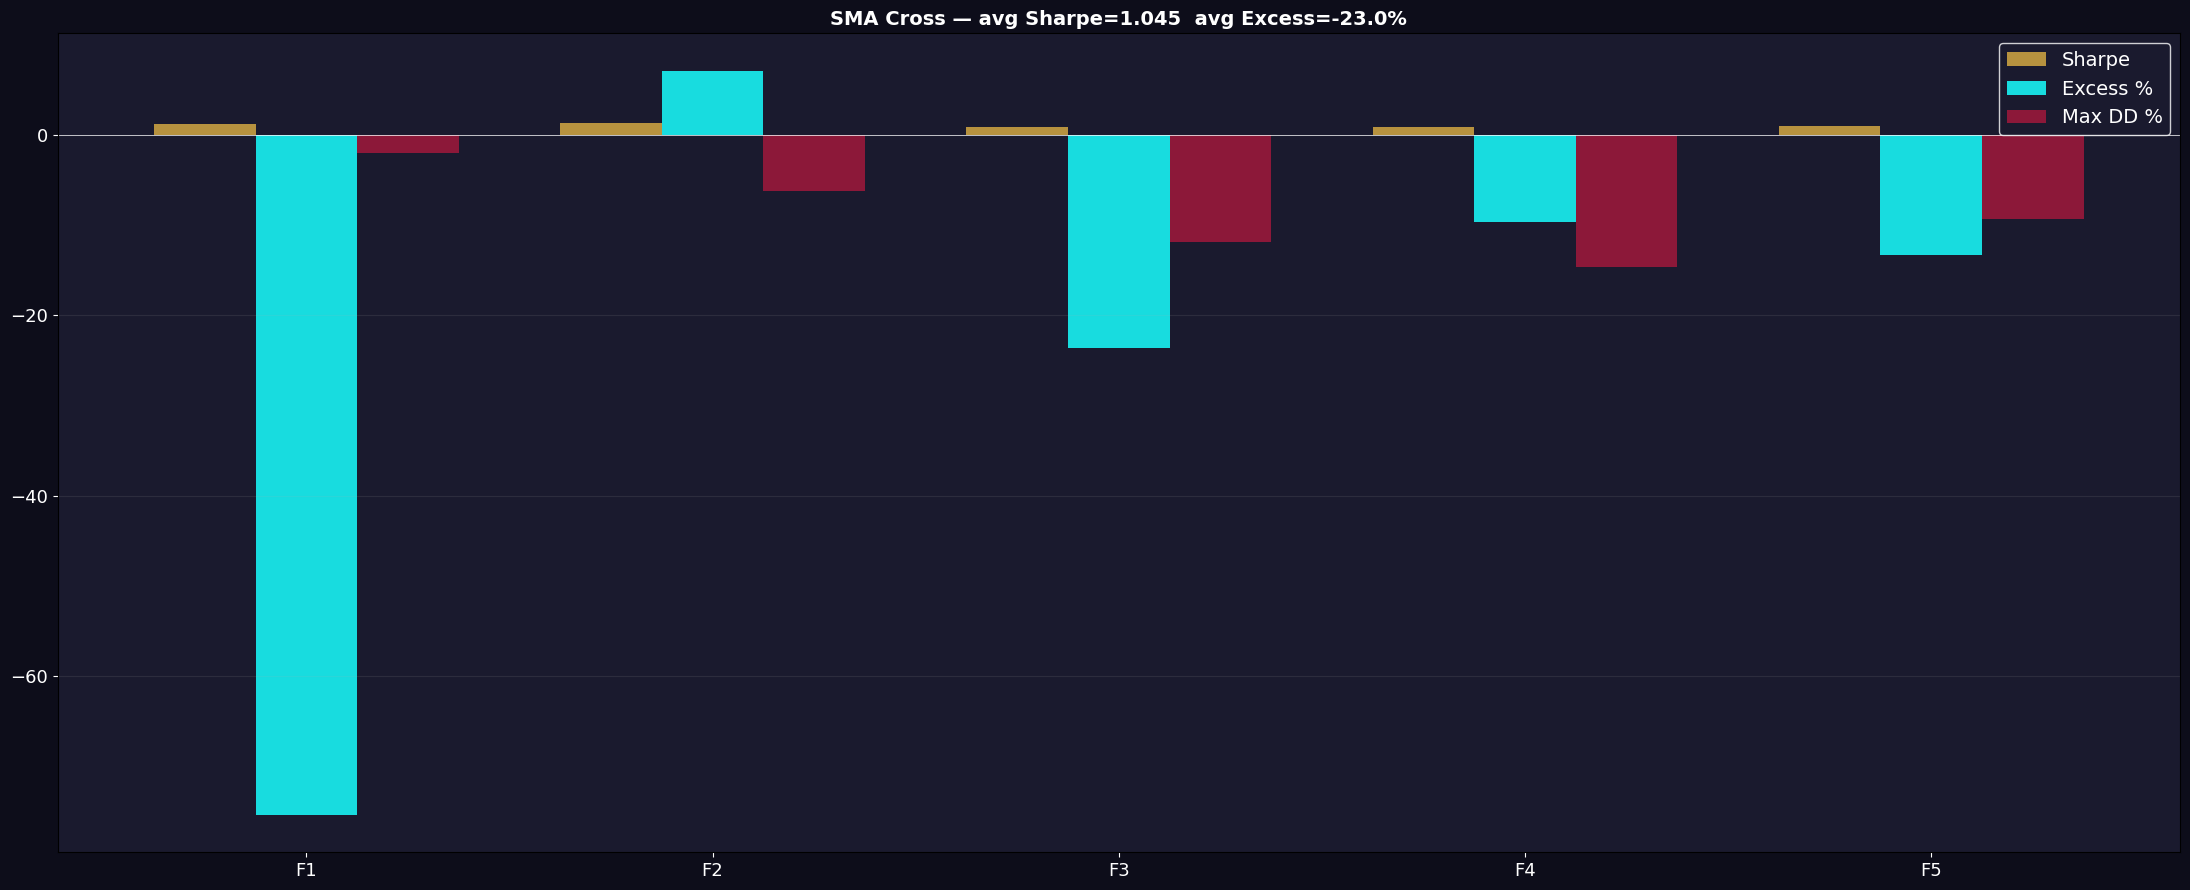

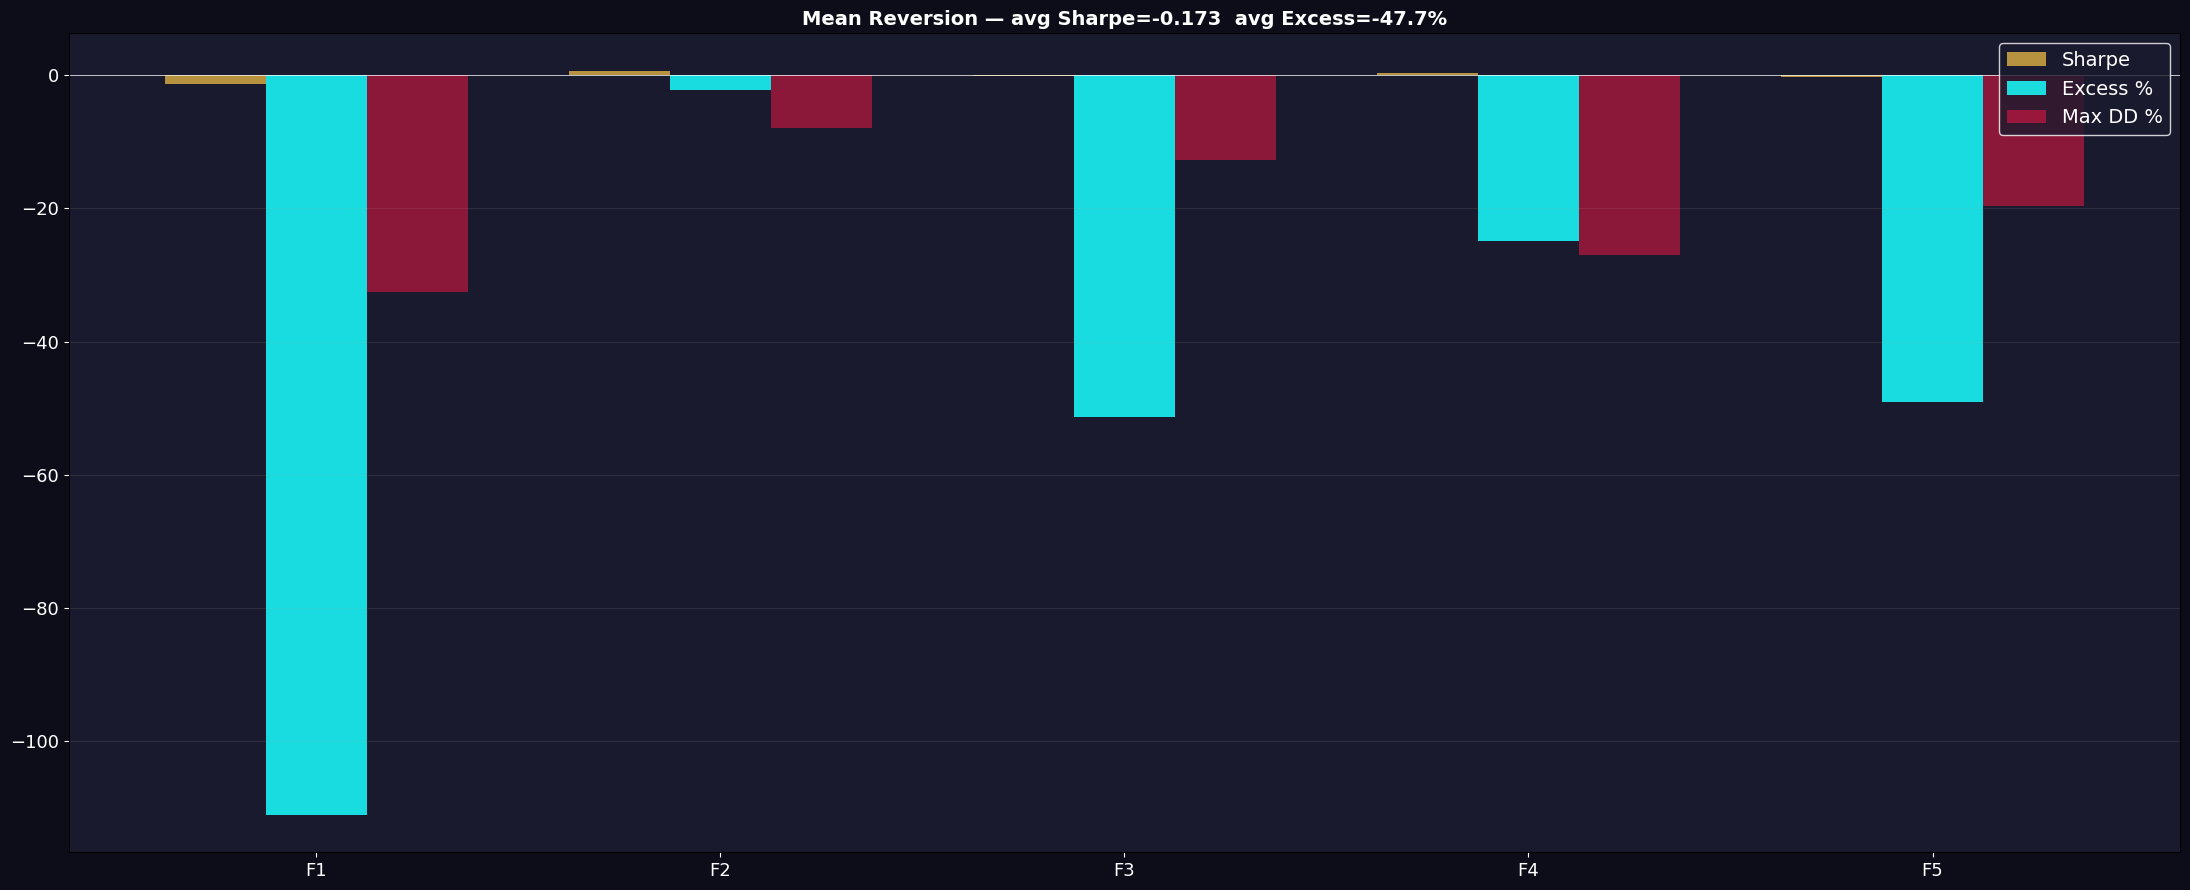

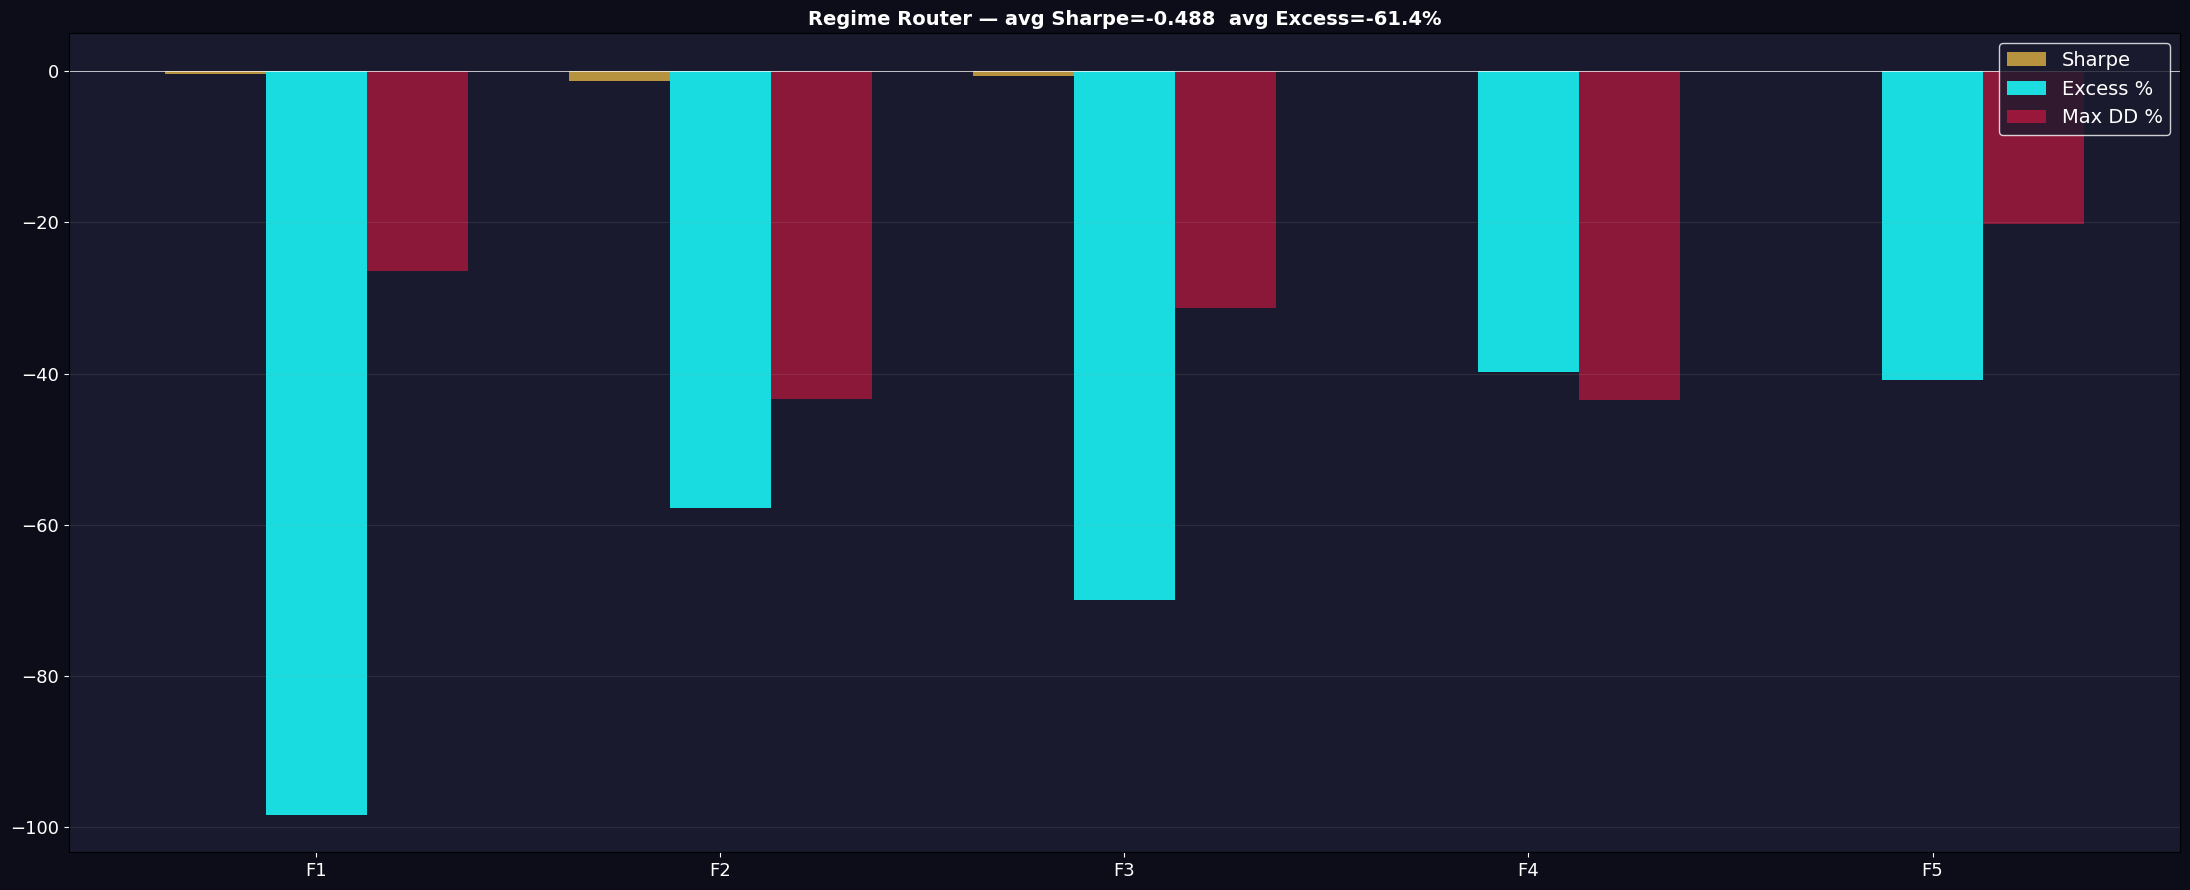

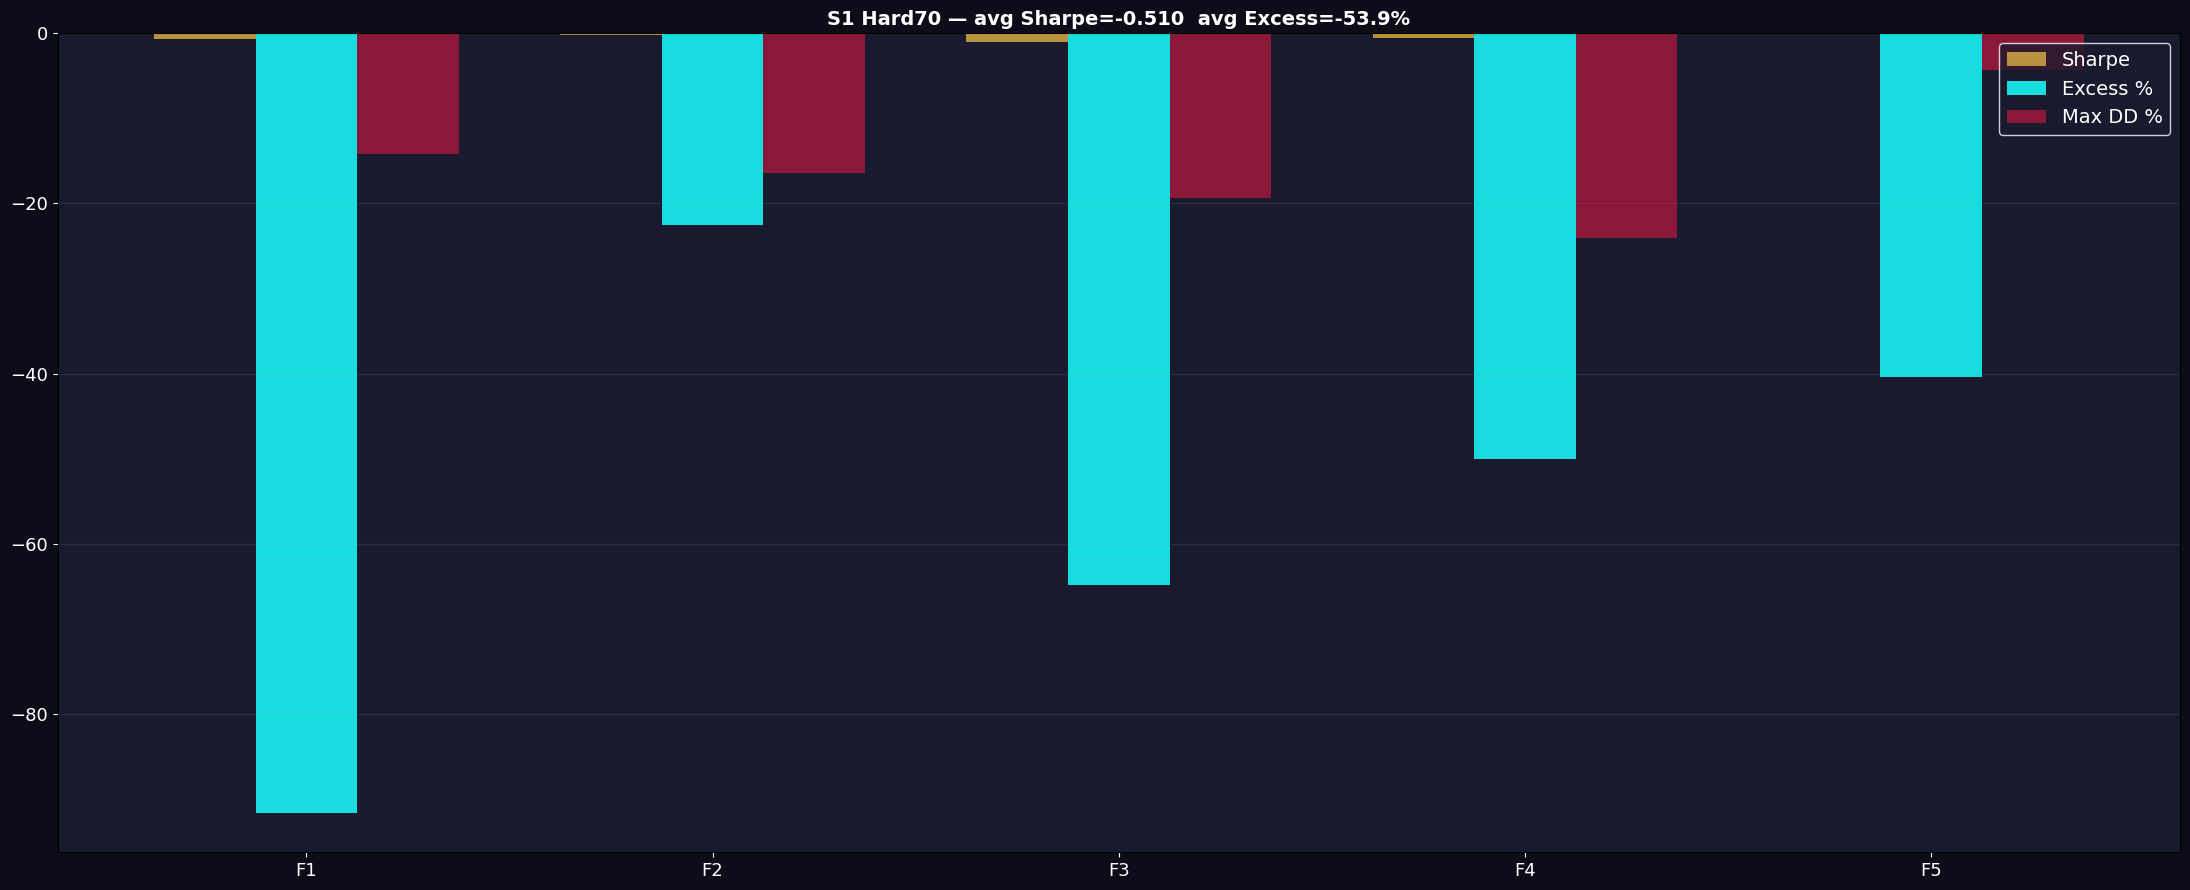

,avg_sharpe,avg_excess_pct,avg_alpha_pct,avg_max_dd_pct
model,,,,
Mean Reversion,-0.173,-47.727,-1.891,-19.987
Regime Router,-0.488,-61.359,-6.245,-32.965
S1 Hard70,-0.510,-53.897,-3.793,-15.669
SMA Cross,1.045,-22.991,4.013,-8.814


In [13]:
def time_split_test(df_in, strategy_class, param_grid, n_splits=5):
    n_rows = len(df_in)
    fold_size = n_rows // (n_splits + 1)
    fold_results = []
    for i in range(n_splits):
        train_end = (i + 1) * fold_size
        test_start = train_end
        test_end = min(test_start + fold_size, n_rows)
        train_df = df_in.iloc[:train_end]
        test_df = df_in.iloc[test_start:test_end]
        if len(train_df) < 100 or len(test_df) < 20:
            continue
        gs = grid_search(train_df, strategy_class, param_grid, config=config, verbose=False)
        best = strategy_class(**gs.best_params)
        r = BacktestEngine(config).run(test_df, best)
        m = r.metrics
        fold_results.append({
            'fold': i + 1, 'train_days': len(train_df), 'test_days': len(test_df),
            'best_params': str(gs.best_params),
            'train_sharpe': gs.best_score,
            'test_sharpe': m['sharpe'], 'test_return_pct': m['total_return_pct'],
            'bh_return_pct': m['bh_return_pct'], 'excess_pct': m['excess_return_pct'],
            'alpha_pct': m['alpha_pct'], 'beta': m['beta'],
            'max_dd_pct': m['max_drawdown_pct'],
        })
    return pd.DataFrame(fold_results)

all_ts = []
for name, (cls, grid) in strategy_grids.items():
    ts = time_split_test(df, cls, grid, n_splits=5)
    ts['model'] = name
    all_ts.append(ts)

ts_all = pd.concat(all_ts, ignore_index=True)

for name in strategy_grids.keys():
    sub = ts_all[ts_all['model'] == name]
    if sub.empty: continue
    
    fig, ax = plt.subplots(figsize=(22, 9))
    fig.patch.set_facecolor(BG)
    x = np.arange(len(sub)); w = 0.25
    ax.bar(x - w, sub['test_sharpe'].values, w, color=GOLD, alpha=0.85, label='Sharpe')
    ax.bar(x, sub['excess_pct'].values, w, color=CYAN, alpha=0.85, label='Excess %')
    dd_vals = [-abs(v) for v in sub['max_dd_pct'].values]
    ax.bar(x + w, dd_vals, w, color=RED, alpha=0.5, label='Max DD %')
    ax.set_xticks(x)
    ax.set_xticklabels([f'F{i+1}' for i in range(len(sub))], color='white', fontsize=13)
    ax.axhline(0, color='white', lw=0.5)
    ax.set_title(f'{name} — avg Sharpe={sub["test_sharpe"].mean():.3f}  avg Excess={sub["excess_pct"].mean():+.1f}%', color='white', fontsize=14, fontweight='bold')
    ax.set_facecolor(PANEL)
    ax.tick_params(colors='white', labelsize=13)
    ax.grid(True, alpha=0.12, axis='y')
    ax.legend(fontsize=14, facecolor=PANEL, edgecolor='white', labelcolor='white', loc='upper right')
    fig.tight_layout()
    fig.savefig(_images / f'final_timesplit_{name.lower().replace(" ","_")}.png', dpi=300, facecolor=BG, edgecolor='none', bbox_inches='tight')
    plt.show()

ts_summary = ts_all.groupby('model').agg({'test_sharpe': 'mean', 'excess_pct': 'mean', 'alpha_pct': 'mean', 'max_dd_pct': 'mean'}).round(3)
ts_summary.columns = ['avg_sharpe', 'avg_excess_pct', 'avg_alpha_pct', 'avg_max_dd_pct']
ts_summary


## 5. Melhor Estratégia — Monte Carlo, Stress e Walk-Forward

Seleciona a estratégia com maior Sharpe no grid search e aplica as três validações sobre o portfólio.

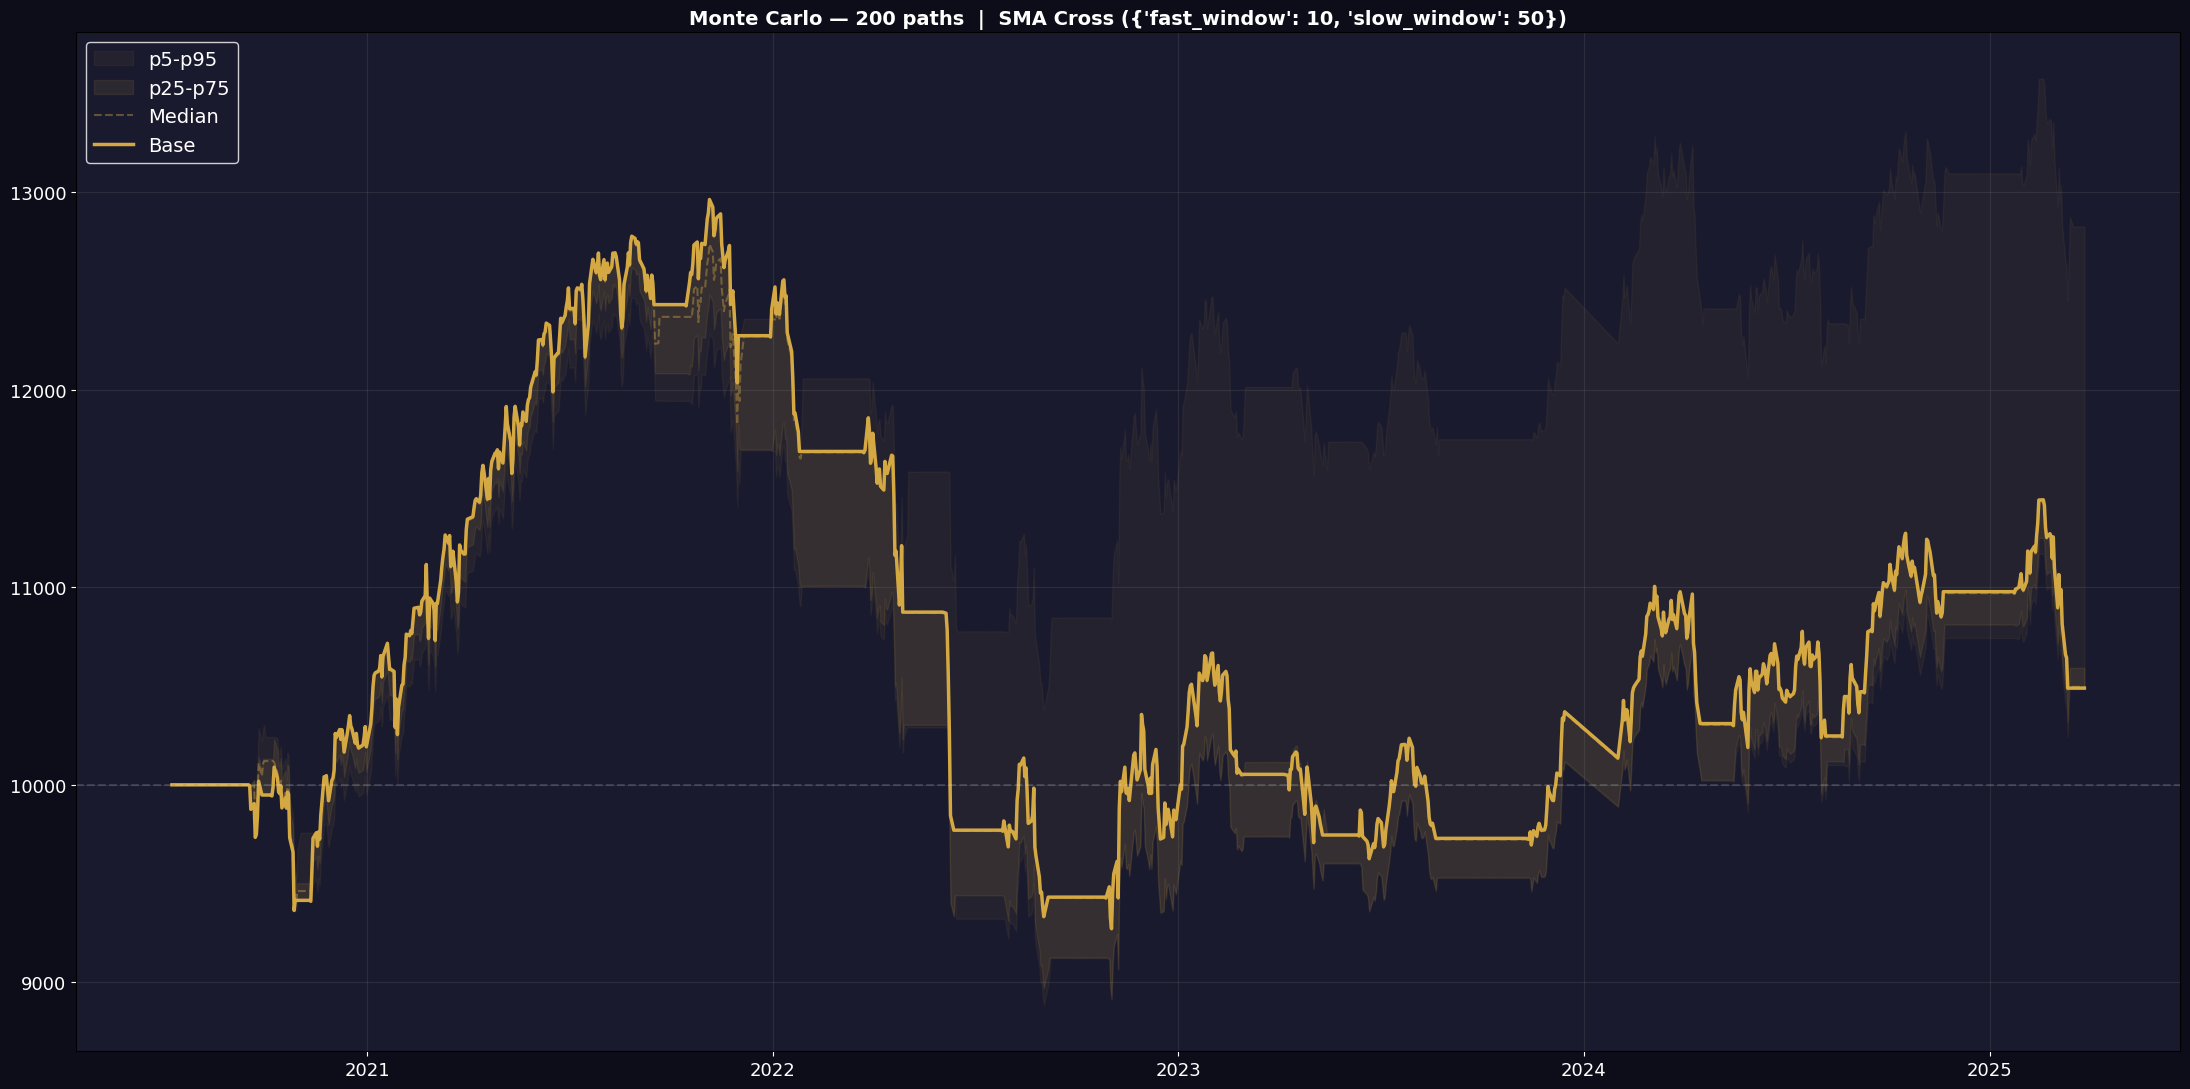

,name,final_equity,total_return_pct,max_drawdown_pct,sharpe,volatility_pct
0,base,10489.756613,4.897566,-28.484210,0.148449,11.456443
1,sim_0,12823.766218,28.237662,-18.737144,0.525061,11.633855
2,sim_1,10492.409566,4.924096,-29.359222,0.148874,11.475462
3,sim_2,10482.170742,4.821719,-28.484463,0.147081,11.452574
4,sim_3,10487.182635,4.871906,-28.488506,0.147991,11.453567
5,sim_4,10587.309121,5.873091,-28.748091,0.165513,11.590803
6,sim_5,10497.577157,4.975772,-29.340576,0.149809,11.476148
7,sim_6,10488.205548,4.882063,-28.479223,0.148177,11.453117
8,sim_7,10493.874642,4.938746,-29.356841,0.149140,11.475330
9,sim_8,10484.146511,4.841466,-28.485201,0.147439,11.453006


In [14]:
best_name = max(heatmap_results, key=lambda n: heatmap_results[n].best_score)
best_cls, best_grid = strategy_grids[best_name]
gs_best = heatmap_results[best_name]
best_strat = best_cls(**gs_best.best_params)

mc = monte_carlo_simulate(df_test, best_strat, MonteCarloConfig(n_simulations=200, noise_bps=8, delay_bars=(0,3), seed=42), config, verbose=False)

base = mc.base_equity.set_index('timestamp')['equity']
pcts = mc.percentile_curves

fig, ax = plt.subplots(figsize=(22, 11))
fig.patch.set_facecolor(BG)
ax.fill_between(base.index, pcts['p5'], pcts['p95'], color=GOLD, alpha=0.06, label='p5-p95')
ax.fill_between(base.index, pcts['p25'], pcts['p75'], color=GOLD, alpha=0.10, label='p25-p75')
ax.plot(base.index, pcts['p50'], color=GOLD, lw=1.5, alpha=0.4, ls='--', label='Median')
ax.plot(base.index, base.values, color=GOLD, lw=2.5, label='Base')
ax.axhline(config.initial_cash, color='white', ls='--', alpha=0.15)
ax.set_title(f'Monte Carlo — 200 paths  |  {best_name} ({gs_best.best_params})', color='white', fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)
ax.tick_params(colors='white', labelsize=13)
ax.grid(True, alpha=0.12)
ax.legend(fontsize=14, facecolor=PANEL, edgecolor='white', labelcolor='white', loc='upper left')
fig.tight_layout()
fig.savefig(_images / 'final_montecarlo.png', dpi=300, facecolor=BG, edgecolor='none', bbox_inches='tight')
plt.show()

mc.summary_metrics.head(17)


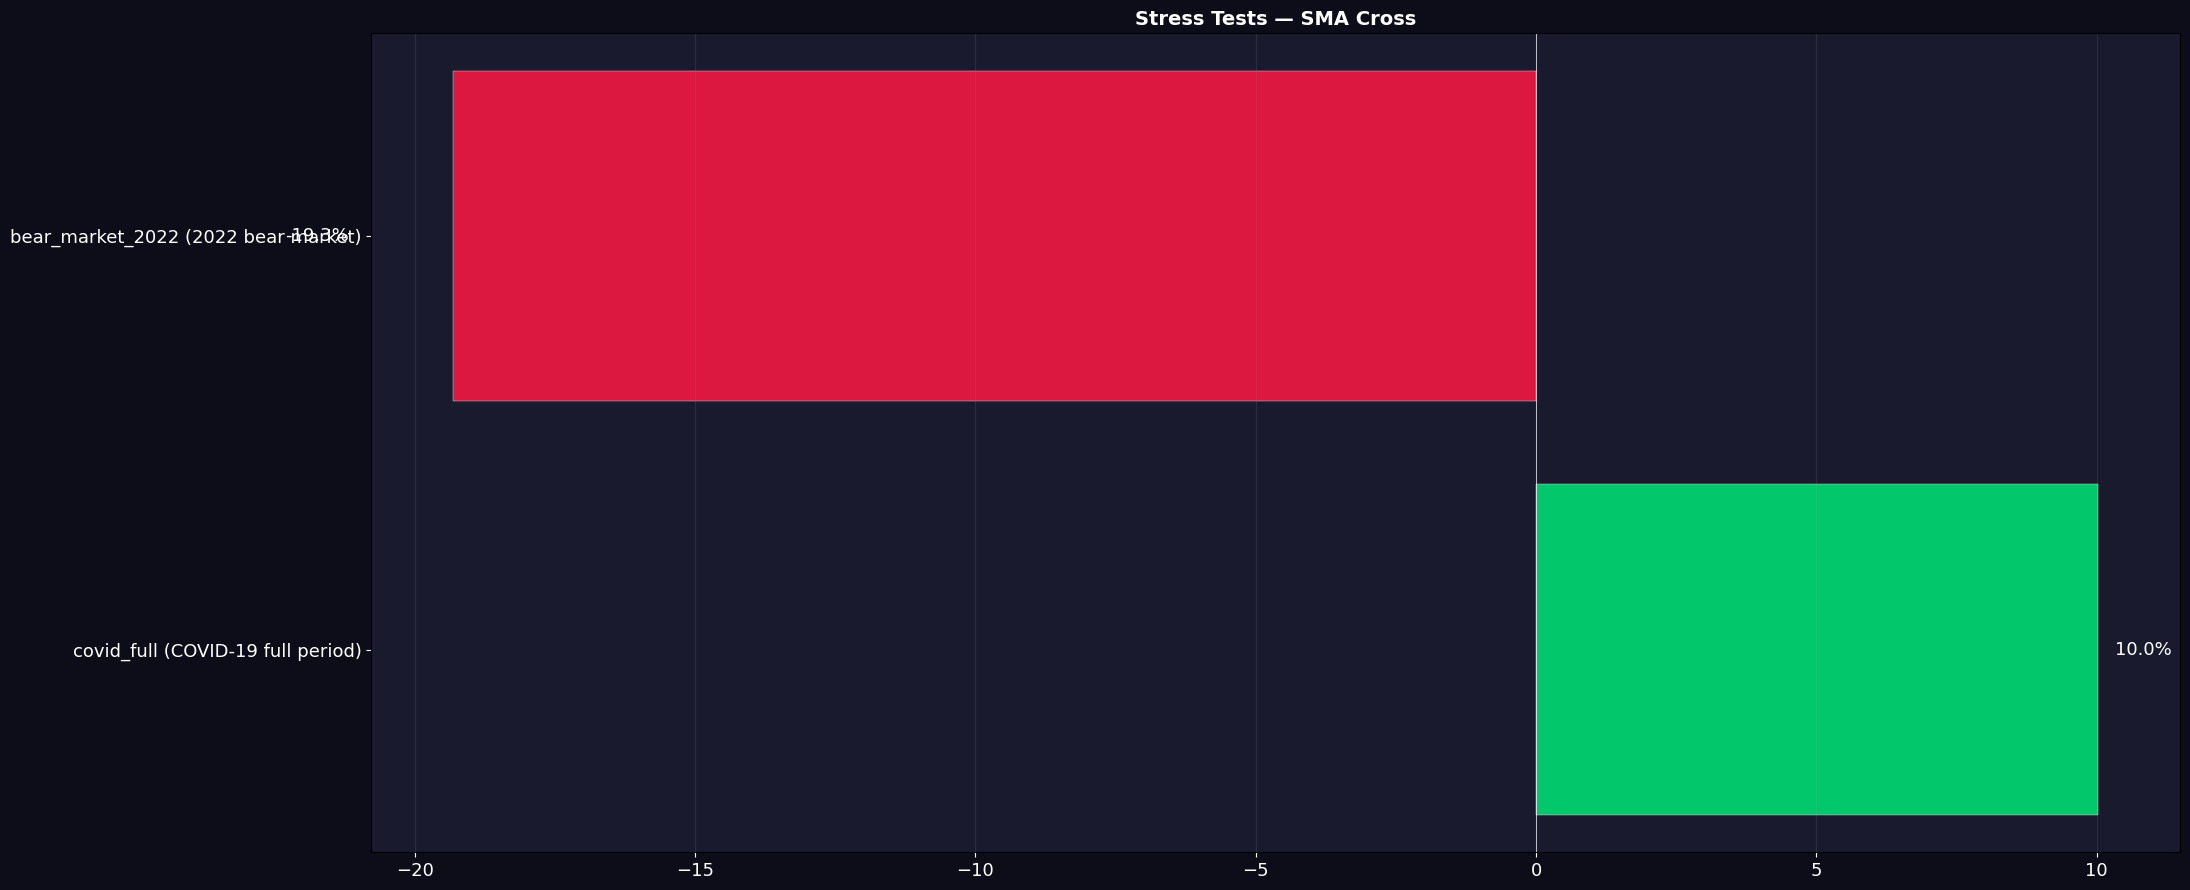

,scenario,description,return_pct,max_drawdown_pct,sharpe
1,covid_full,COVID-19 full period,10.019740,-8.411971,1.173881
2,bear_market_2022,2022 bear market,-19.309988,-21.301930,-2.392138


In [15]:
st = run_stress_tests(df, best_strat, config=config, verbose=False)
sdf = st.summary[st.summary['return_pct'] != 0].copy()
if sdf.empty: sdf = st.summary.head(4)

fig, ax = plt.subplots(figsize=(22, 9))
fig.patch.set_facecolor(BG)
y_pos = np.arange(len(sdf))
rets = sdf['return_pct'].values
ax.barh(y_pos, rets, color=[GREEN if v >= 0 else RED for v in rets], alpha=0.85, edgecolor='white', lw=0.3)
ax.set_yticks(y_pos)
ax.set_yticklabels([f'{sdf.iloc[i]["scenario"]} ({sdf.iloc[i]["description"]})' for i in range(len(sdf))], color='white', fontsize=13)
ax.axvline(0, color='white', lw=0.5)
for i, v in enumerate(rets):
    ax.text(v + (0.3 if v >= 0 else -3), i, f'{v:.1f}%', va='center', color='white', fontsize=13)
ax.set_title(f'Stress Tests — {best_name}', color='white', fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)
ax.tick_params(colors='white', labelsize=13)
ax.grid(True, alpha=0.12, axis='x')
fig.tight_layout()
fig.savefig(_images / 'final_stress.png', dpi=300, facecolor=BG, edgecolor='none', bbox_inches='tight')
plt.show()

sdf[['scenario', 'description', 'return_pct', 'max_drawdown_pct', 'sharpe']]


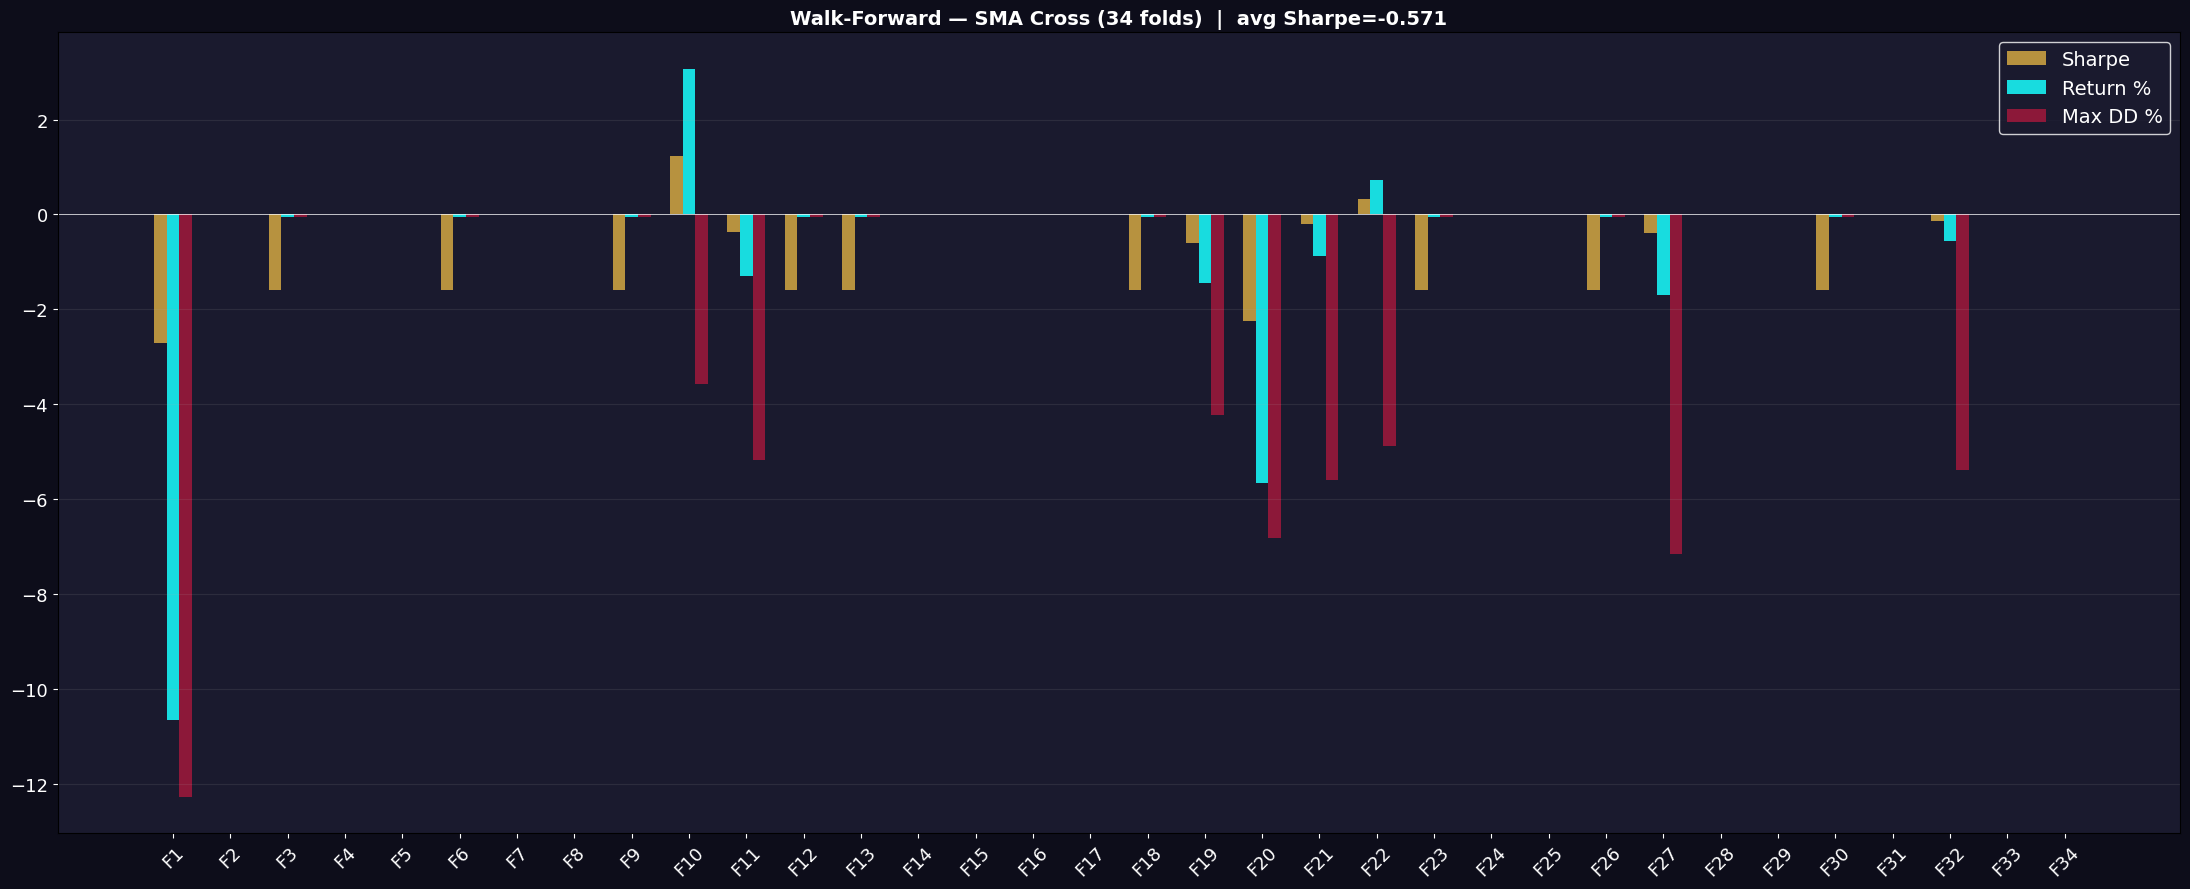

,fold,best_params,test_sharpe,test_total_return_pct,test_max_drawdown_pct
0,1,"{'fast_window': 5, 'slow_window': 50}",-2.703696,-10.658244,-12.275445
1,2,"{'fast_window': 100, 'slow_window': 50}",0.000000,0.000000,0.000000
2,3,"{'fast_window': 100, 'slow_window': 50}",-1.587451,-0.050004,-0.050004
3,4,"{'fast_window': 100, 'slow_window': 50}",0.000000,0.000000,0.000000
4,5,"{'fast_window': 50, 'slow_window': 50}",0.000000,0.000000,0.000000
5,6,"{'fast_window': 20, 'slow_window': 100}",-1.587451,-0.050004,-0.050004
6,7,"{'fast_window': 100, 'slow_window': 50}",0.000000,0.000000,0.000000
7,8,"{'fast_window': 50, 'slow_window': 200}",0.000000,0.000000,0.000000
8,9,"{'fast_window': 5, 'slow_window': 100}",-1.587451,-0.050004,-0.050004
9,10,"{'fast_window': 5, 'slow_window': 50}",1.240362,3.071732,-3.574198


In [16]:
wf = walk_forward_optimize(df, best_cls, best_grid, WalkForwardConfig(train_window=300, test_window=100, min_train=100, purge_bars=10), metric='sharpe', engine_config=config, verbose=False)

folds = wf.fold_results
fig, ax = plt.subplots(figsize=(22, 9))
fig.patch.set_facecolor(BG)
x = np.arange(len(folds)); w = 0.22
s_vals = [f.get('test_sharpe', 0) for f in folds]
r_vals = [f.get('test_total_return_pct', 0) for f in folds]
d_vals = [-abs(f.get('test_max_drawdown_pct', 0)) for f in folds]
ax.bar(x - w, s_vals, w, color=GOLD, alpha=0.85, label='Sharpe')
ax.bar(x, r_vals, w, color=CYAN, alpha=0.85, label='Return %')
ax.bar(x + w, d_vals, w, color=RED, alpha=0.5, label='Max DD %')
ax.set_xticks(x)
ax.set_xticklabels([f'F{f["fold"]}' for f in folds], color='white', fontsize=13, rotation=45)
ax.axhline(0, color='white', lw=0.5)
ax.set_title(f'Walk-Forward — {best_name} ({len(folds)} folds)  |  avg Sharpe={wf.aggregate_metrics.get("avg_sharpe",0):.3f}', color='white', fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)
ax.tick_params(colors='white', labelsize=13)
ax.grid(True, alpha=0.12, axis='y')
ax.legend(fontsize=14, facecolor=PANEL, edgecolor='white', labelcolor='white', loc='upper right')
fig.tight_layout()
fig.savefig(_images / 'final_walkforward.png', dpi=300, facecolor=BG, edgecolor='none', bbox_inches='tight')
plt.show()

pd.DataFrame(folds)[['fold', 'best_params', 'test_sharpe', 'test_total_return_pct', 'test_max_drawdown_pct']].head(10)


## 6. Curva Final + Métricas Completas

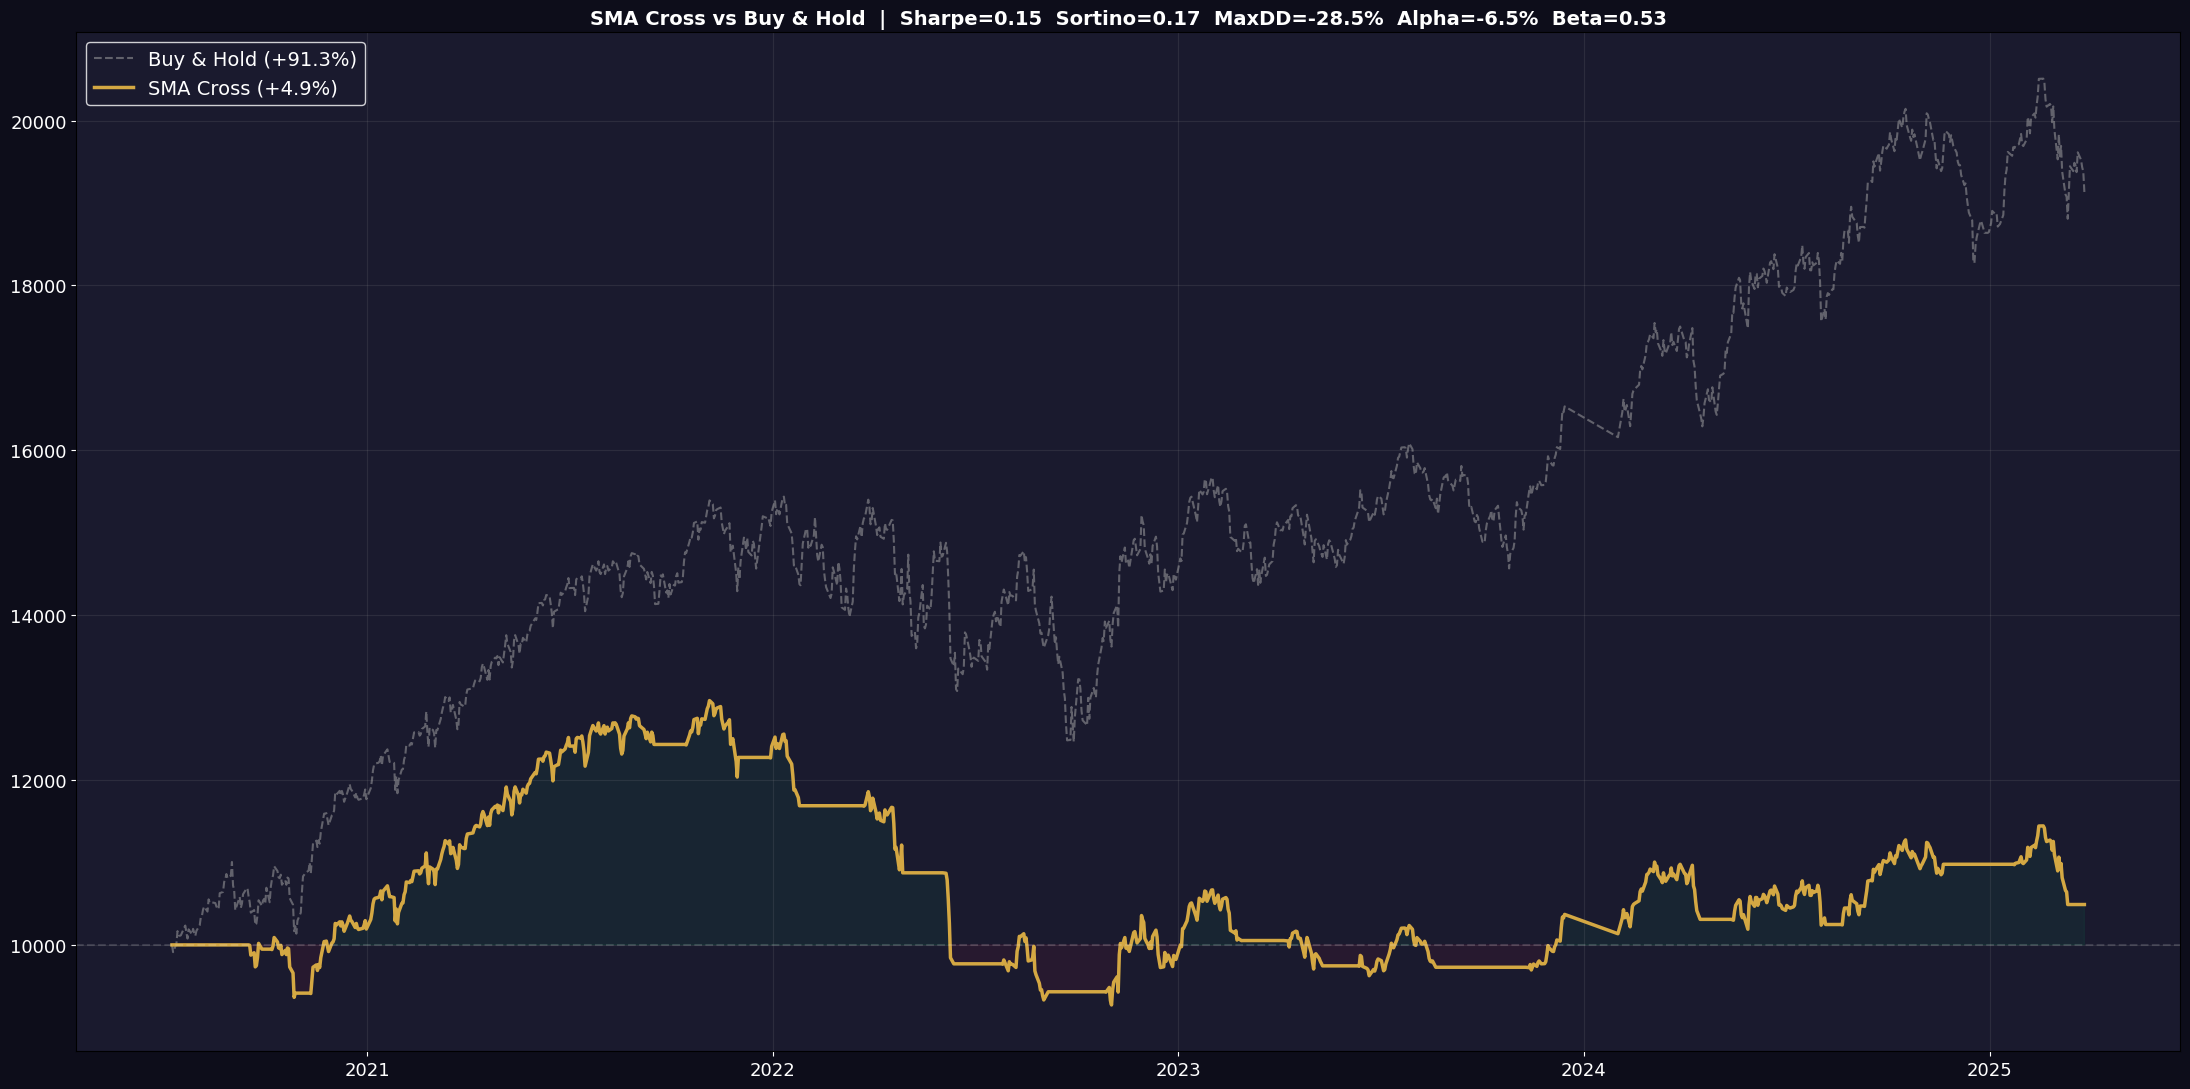

,value
alpha_pct,-6.51
alpha_return_pct,-6.51
avg_trade_pct,-2282.79
beta,0.53
beta_return_pct,8.21
bh_return_pct,91.34
cagr_pct,1.05
calmar,0.04
capm_alpha,-6.51
capm_beta,0.53


In [17]:
r_final = BacktestEngine(config).run(df_test, best_strat)
eq = r_final.equity_curve.set_index('timestamp')['equity']
bh = df_test.set_index('timestamp')['close'] / df_test['close'].iloc[0] * config.initial_cash

fig, ax = plt.subplots(figsize=(22, 11))
fig.patch.set_facecolor(BG)
ax.plot(bh.index, bh.values, color=WHITE, lw=1.5, ls='--', alpha=0.5, label=f'Buy & Hold ({r_final.metrics["bh_return_pct"]:+.1f}%)')
ax.plot(eq.index, eq.values, color=GOLD, lw=2.5, label=f'{best_name} ({r_final.metrics["total_return_pct"]:+.1f}%)')
ax.fill_between(eq.index, eq.values, config.initial_cash, where=eq.values >= config.initial_cash, color=GREEN, alpha=0.06)
ax.fill_between(eq.index, eq.values, config.initial_cash, where=eq.values < config.initial_cash, color=RED, alpha=0.06)
ax.axhline(config.initial_cash, color='white', ls='--', alpha=0.15)
m = r_final.metrics
ax.set_title(f'{best_name} vs Buy & Hold  |  Sharpe={m["sharpe"]:.2f}  Sortino={m["sortino"]:.2f}  MaxDD={m["max_drawdown_pct"]:.1f}%  Alpha={m["alpha_pct"]:+.1f}%  Beta={m["beta"]:.2f}', color='white', fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)
ax.tick_params(colors='white', labelsize=13)
ax.grid(True, alpha=0.12)
ax.legend(fontsize=14, facecolor=PANEL, edgecolor='white', labelcolor='white', loc='upper left')
fig.tight_layout()
fig.savefig(_images / 'final_equity.png', dpi=300, facecolor=BG, edgecolor='none', bbox_inches='tight')
plt.show()

pd.Series({k: round(v, 2) if isinstance(v, float) else v for k, v in sorted(r_final.metrics.items())}).to_frame('value')


## 6b. Análise Detalhada

Rolling metrics, distribuição de retornos, regime breakdown, contribuição por ticker e tail risk.

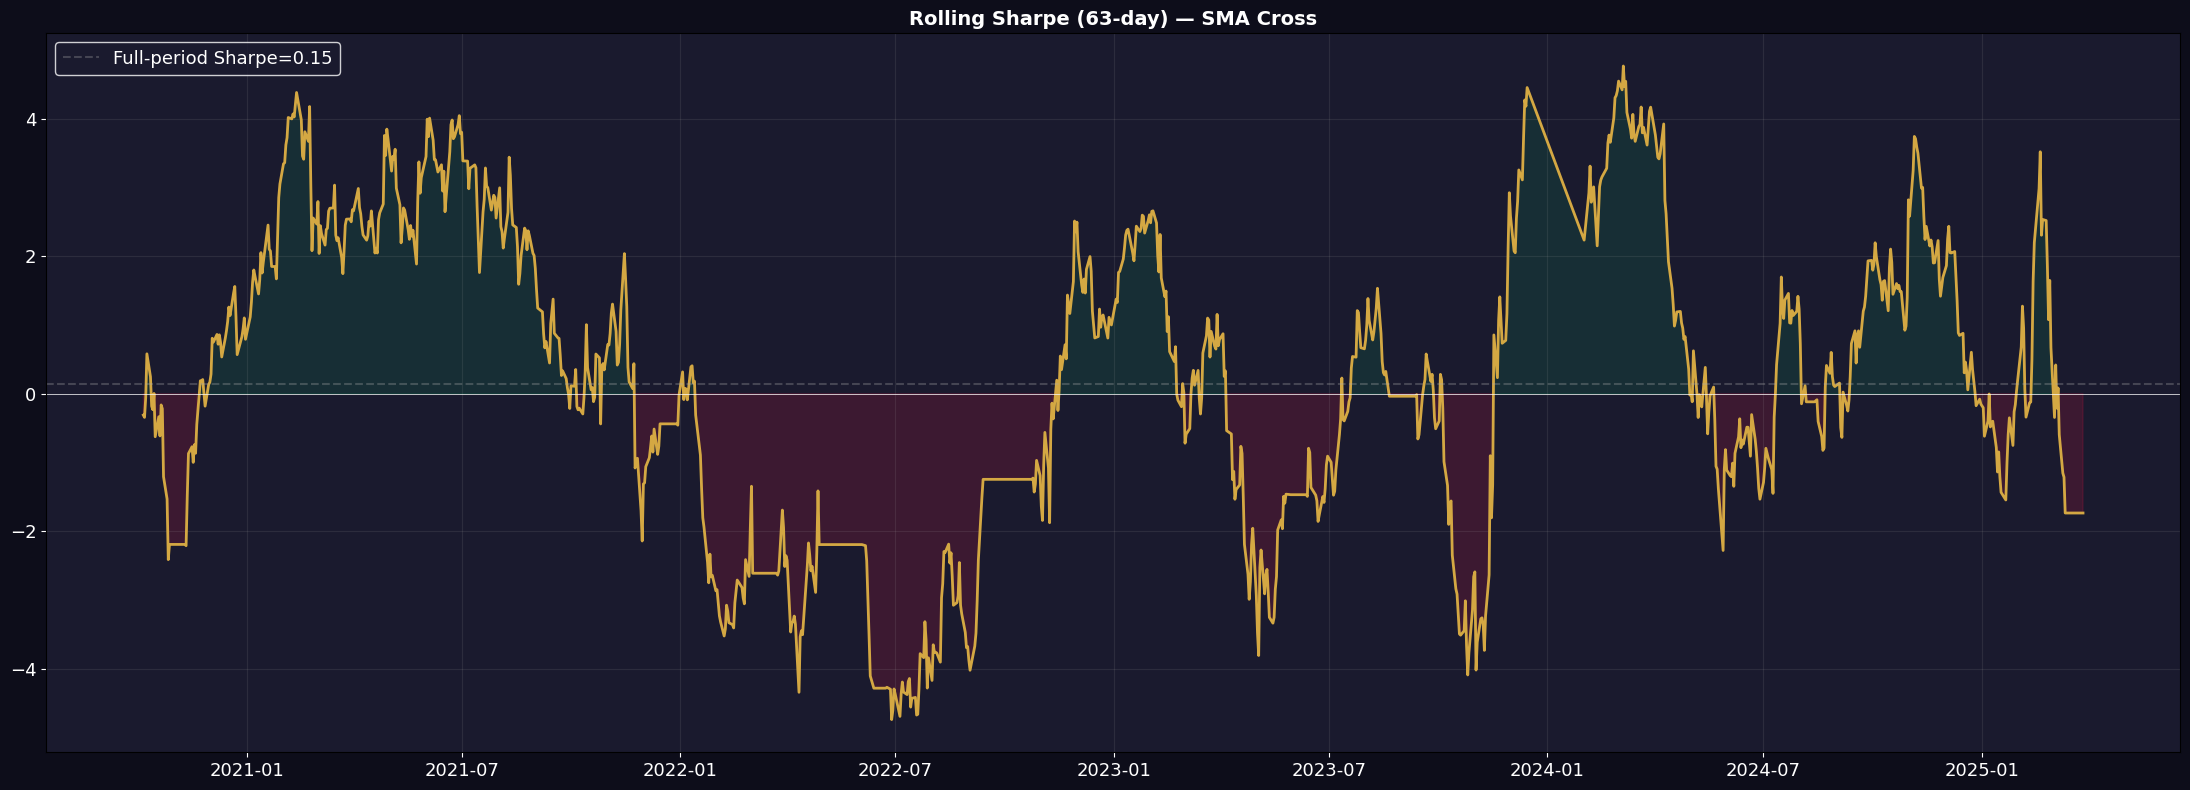

,value
count,1093.000000
mean,0.161321
std,2.173328
min,-4.741556
25%,-1.380887
50%,0.148154
75%,1.912997
max,4.770027


In [18]:
ret_test = df_test.set_index('timestamp')['close'].pct_change().fillna(0.0)
strat_ret_test = r_final.equity_curve.set_index('timestamp')['equity'].pct_change().fillna(0.0)
if strat_ret_test.index.tz is not None:
    strat_ret_test.index = strat_ret_test.index.tz_localize(None)
if ret_test.index.tz is not None:
    ret_test.index = ret_test.index.tz_localize(None)

window = 63
roll_sharpe = (strat_ret_test.rolling(window).mean() / strat_ret_test.rolling(window).std()) * np.sqrt(252)
roll_sharpe = roll_sharpe.dropna()

fig, ax = plt.subplots(figsize=(22, 8))
fig.patch.set_facecolor(BG)
ax.plot(roll_sharpe.index, roll_sharpe.values, color=GOLD, lw=2)
ax.fill_between(roll_sharpe.index, 0, roll_sharpe.values, where=roll_sharpe.values >= 0, color=GREEN, alpha=0.10)
ax.fill_between(roll_sharpe.index, 0, roll_sharpe.values, where=roll_sharpe.values < 0, color=RED, alpha=0.15)
ax.axhline(0, color='white', lw=0.5)
ax.axhline(r_final.metrics['sharpe'], color=WHITE, ls='--', alpha=0.3, label=f'Full-period Sharpe={r_final.metrics["sharpe"]:.2f}')
ax.set_title(f'Rolling Sharpe (63-day) — {best_name}', color='white', fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)
ax.tick_params(colors='white', labelsize=13)
ax.grid(True, alpha=0.12)
ax.legend(fontsize=13, facecolor=PANEL, edgecolor='white', labelcolor='white', loc='upper left')
fig.tight_layout()
fig.savefig(_images / 'final_rolling_sharpe.png', dpi=300, facecolor=BG, edgecolor='none', bbox_inches='tight')
plt.show()

roll_sharpe.describe().to_frame('value')


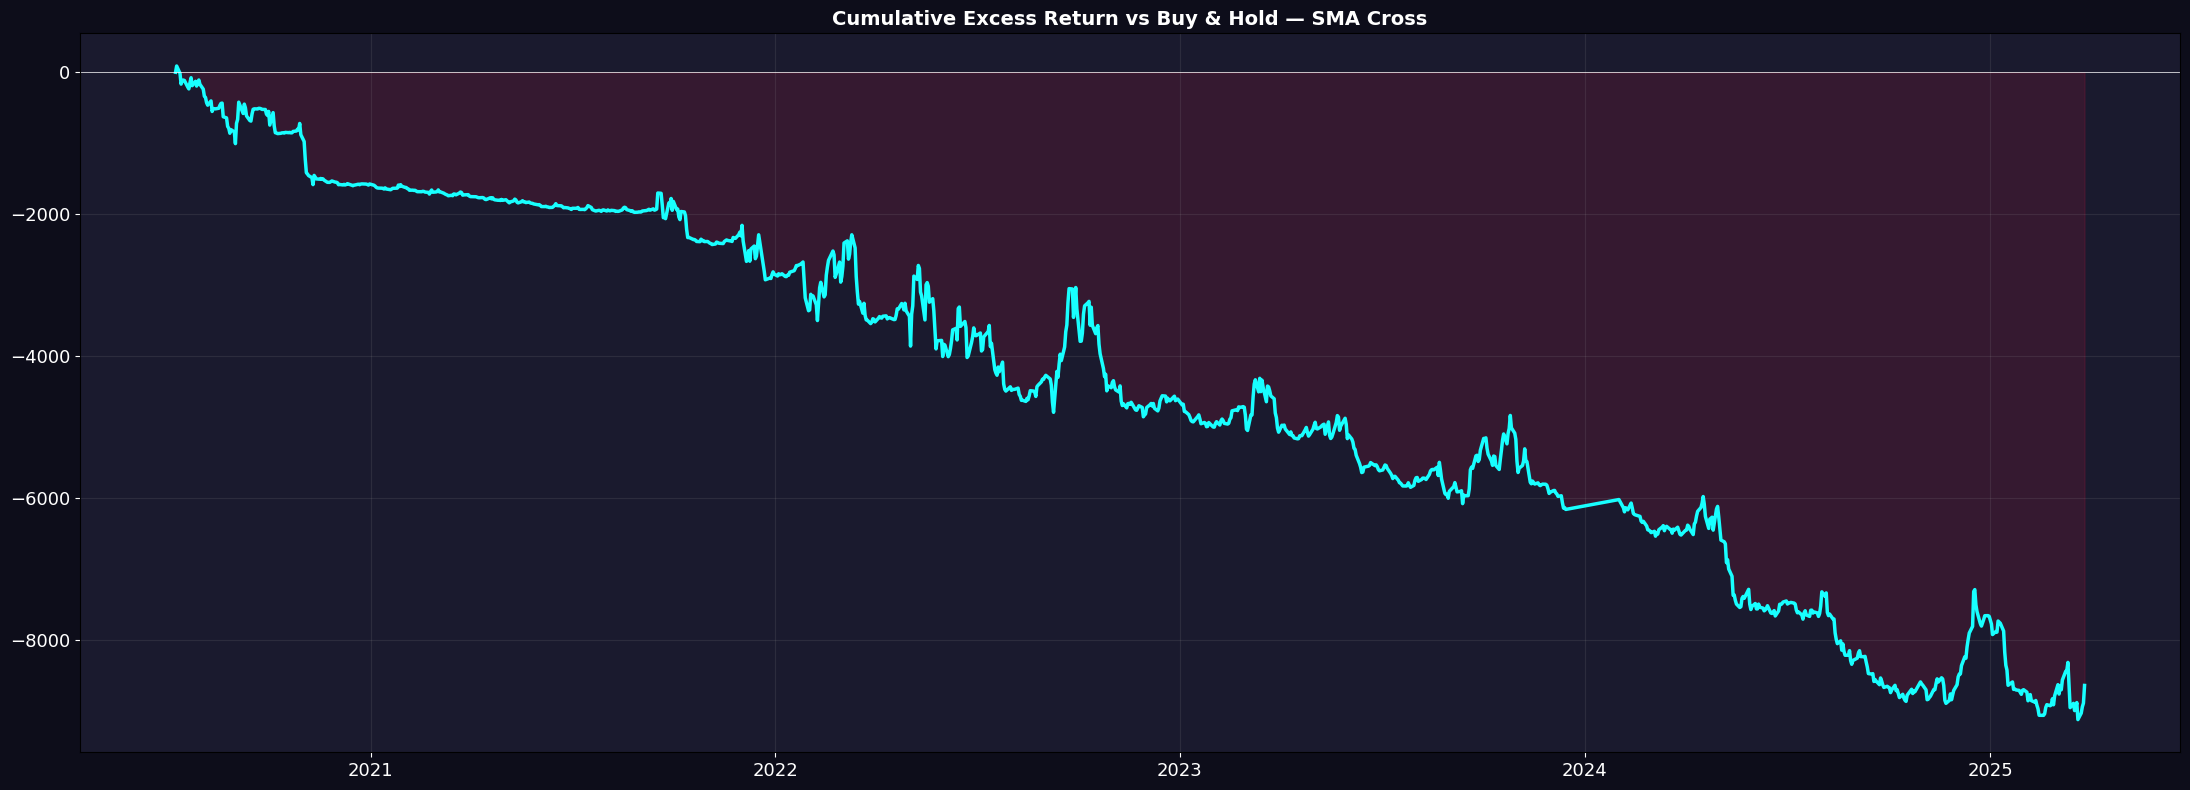

-8643.823166408125

In [19]:
cum_strat = (1 + strat_ret_test).cumprod() * 100
cum_bh = (1 + ret_test).cumprod() * 100
excess = (cum_strat - cum_bh) / 100 * config.initial_cash

fig, ax = plt.subplots(figsize=(22, 8))
fig.patch.set_facecolor(BG)
ax.plot(excess.index, excess.values, color=CYAN, lw=2.5)
ax.fill_between(excess.index, 0, excess.values, where=excess.values >= 0, color=GREEN, alpha=0.12)
ax.fill_between(excess.index, 0, excess.values, where=excess.values < 0, color=RED, alpha=0.12)
ax.axhline(0, color='white', lw=0.5)
ax.set_title(f'Cumulative Excess Return vs Buy & Hold — {best_name}', color='white', fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)
ax.tick_params(colors='white', labelsize=13)
ax.grid(True, alpha=0.12)
fig.tight_layout()
fig.savefig(_images / 'final_cumulative_excess.png', dpi=300, facecolor=BG, edgecolor='none', bbox_inches='tight')
plt.show()

excess.iloc[-1]


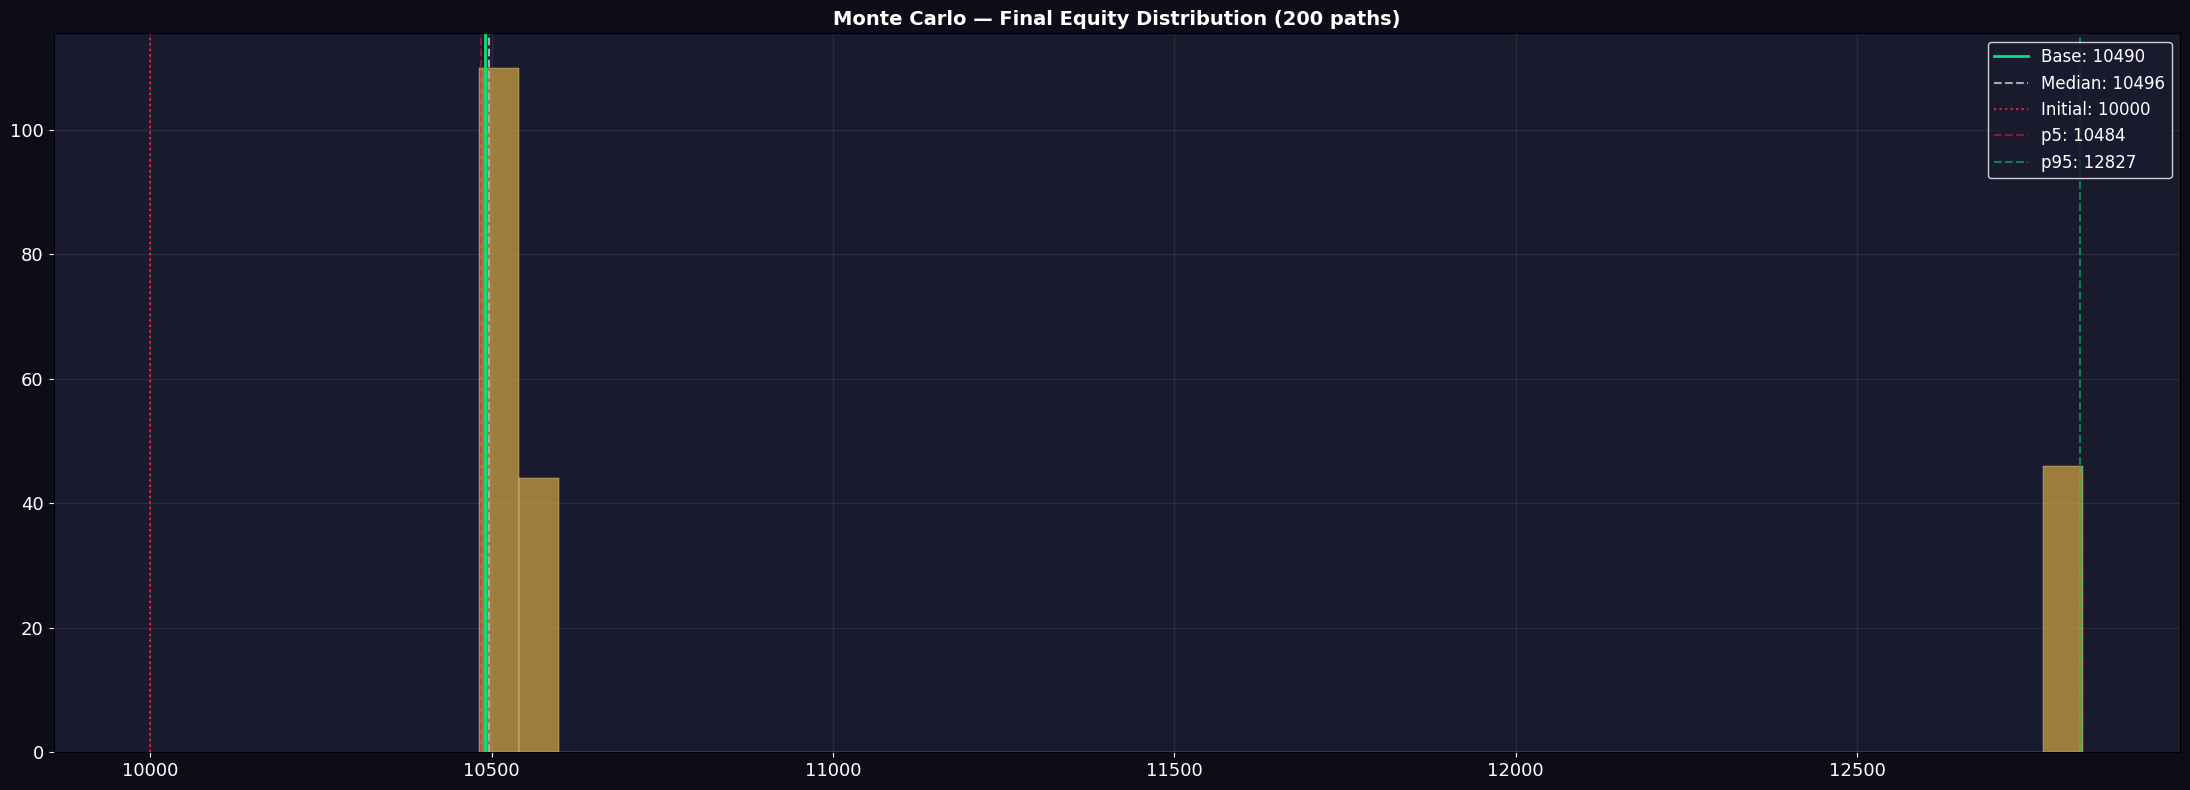

,p1,p5,median,mean,p95,p99,std,base
0,10482.169515,10483.733678,10496.270047,11048.534033,12826.932423,12829.193607,971.233496,10489.756613


In [20]:
sim_finals = np.array([s.iloc[-1] for s in mc.simulations])
base_final = mc.base_equity.set_index('timestamp')['equity'].iloc[-1]

fig, ax = plt.subplots(figsize=(22, 8))
fig.patch.set_facecolor(BG)
ax.hist(sim_finals, bins=40, color=GOLD, alpha=0.7, edgecolor='white', lw=0.3)
ax.axvline(base_final, color=GREEN, lw=2, label=f'Base: {base_final:.0f}')
ax.axvline(np.median(sim_finals), color=WHITE, ls='--', lw=1.5, label=f'Median: {np.median(sim_finals):.0f}')
ax.axvline(config.initial_cash, color=RED, ls=':', lw=1.5, label=f'Initial: {config.initial_cash:.0f}')
p5, p95 = np.percentile(sim_finals, [5, 95])
ax.axvline(p5, color=RED, ls='--', alpha=0.5, label=f'p5: {p5:.0f}')
ax.axvline(p95, color=GREEN, ls='--', alpha=0.5, label=f'p95: {p95:.0f}')
ax.set_title(f'Monte Carlo — Final Equity Distribution (200 paths)', color='white', fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)
ax.tick_params(colors='white', labelsize=13)
ax.grid(True, alpha=0.12)
ax.legend(fontsize=12, facecolor=PANEL, edgecolor='white', labelcolor='white', loc='upper right')
fig.tight_layout()
fig.savefig(_images / 'final_mc_distribution.png', dpi=300, facecolor=BG, edgecolor='none', bbox_inches='tight')
plt.show()

pd.DataFrame({
    'p1': [np.percentile(sim_finals, 1)], 'p5': [np.percentile(sim_finals, 5)],
    'median': [np.median(sim_finals)], 'mean': [sim_finals.mean()],
    'p95': [np.percentile(sim_finals, 95)], 'p99': [np.percentile(sim_finals, 99)],
    'std': [sim_finals.std()], 'base': [base_final]
})


In [21]:
vol_20 = ret_test.rolling(20).std()
regime_test = (vol_20 > vol_20.median()).fillna(0.0)

high_vol = regime_test[regime_test == 1].index
low_vol = regime_test[regime_test == 0].index

def regime_stats(rets):
    r = rets.dropna()
    if len(r) < 5: return {'days': 0, 'return_pct': 0, 'sharpe': 0, 'vol': 0}
    t = (1 + r).prod() - 1
    v = r.std() * np.sqrt(252)
    s = (r.mean() / r.std()) * np.sqrt(252) if r.std() > 0 else 0
    return {'days': len(r), 'return_pct': t*100, 'sharpe': s, 'vol_pct': v*100}

rows = [
    {'regime': 'High Vol (strategy)', **regime_stats(strat_ret_test.loc[high_vol])},
    {'regime': 'High Vol (BH)',       **regime_stats(ret_test.loc[high_vol])},
    {'regime': 'Low Vol (strategy)',  **regime_stats(strat_ret_test.loc[low_vol])},
    {'regime': 'Low Vol (BH)',        **regime_stats(ret_test.loc[low_vol])},
]
pd.DataFrame(rows).set_index('regime')


,days,return_pct,sharpe,vol_pct
regime,,,,
High Vol (strategy),568,-0.633312,0.045047,13.265681
High Vol (BH),568,58.810104,1.165544,19.191249
Low Vol (strategy),587,5.566129,0.294835,9.378856
Low Vol (BH),587,20.480872,0.766094,11.271416


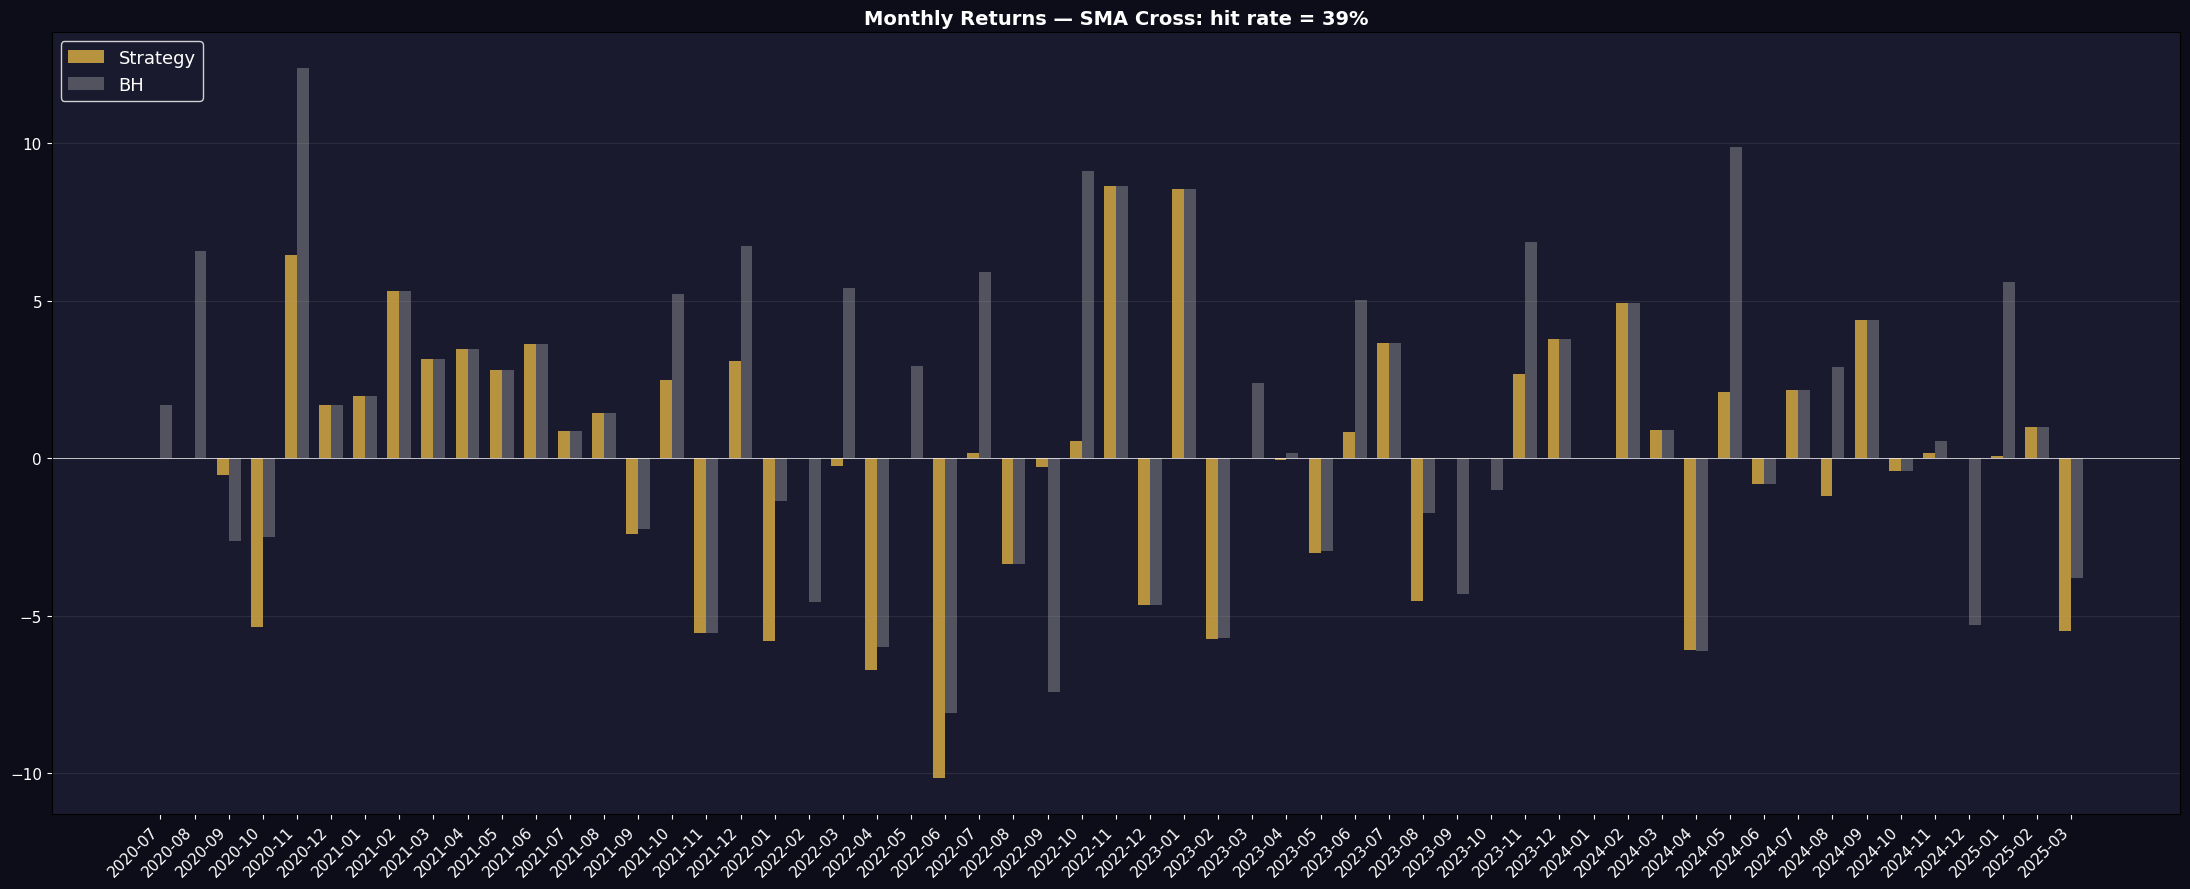

,strategy,bh,excess,hit
count,57.0000,57.0000,57.0000,57.0000
mean,0.0015,0.0125,-0.0110,0.3860
std,0.0375,0.0476,0.0298,0.4911
min,-0.1015,-0.0809,-0.0858,0.0000
25%,-0.0082,-0.0249,-0.0277,0.0000
50%,0.0000,0.0169,-0.0000,0.0000
75%,0.0250,0.0493,0.0000,1.0000
max,0.0866,0.1240,0.0714,1.0000


In [22]:
strat_monthly = strat_ret_test.resample('M').apply(lambda x: (1 + x).prod() - 1)
bh_monthly = ret_test.resample('M').apply(lambda x: (1 + x).prod() - 1)

months_df = pd.DataFrame({'strategy': strat_monthly, 'bh': bh_monthly}).dropna()
months_df['excess'] = months_df['strategy'] - months_df['bh']
months_df['hit'] = (months_df['strategy'] > months_df['bh']).astype(int)

fig, ax = plt.subplots(figsize=(22, 9))
fig.patch.set_facecolor(BG)
x = np.arange(len(months_df))
w = 0.35
ax.bar(x - w/2, months_df['strategy'].values * 100, w, color=GOLD, alpha=0.85, label='Strategy')
ax.bar(x + w/2, months_df['bh'].values * 100, w, color=WHITE, alpha=0.4, label='BH')
ax.set_xticks(x)
ax.set_xticklabels([d.strftime('%Y-%m') for d in months_df.index], color='white', fontsize=11, rotation=45, ha='right')
ax.axhline(0, color='white', lw=0.5)
ax.set_title(f'Monthly Returns — {best_name}: hit rate = {months_df["hit"].mean()*100:.0f}%', color='white', fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)
ax.tick_params(colors='white', labelsize=11)
ax.grid(True, alpha=0.12, axis='y')
ax.legend(fontsize=13, facecolor=PANEL, edgecolor='white', labelcolor='white', loc='upper left')
fig.tight_layout()
fig.savefig(_images / 'final_monthly_returns.png', dpi=300, facecolor=BG, edgecolor='none', bbox_inches='tight')
plt.show()

months_df.describe().round(4)


In [23]:
from scipy.stats import norm

tail_rows = []
for name, rets in [('Strategy', strat_ret_test), ('BH', ret_test)]:
    r = rets.dropna()
    tail_rows.append({
        'name': name,
        'worst_day_pct': r.min() * 100,
        'best_day_pct': r.max() * 100,
        'var_95_pct': r.quantile(0.05) * 100,
        'var_99_pct': r.quantile(0.01) * 100,
        'es_95_pct': r[r <= r.quantile(0.05)].mean() * 100,
        'es_99_pct': r[r <= r.quantile(0.01)].mean() * 100,
        'kurtosis': r.kurtosis(),
        'skew': r.skew(),
    })

pd.DataFrame(tail_rows).set_index('name').round(2)


,worst_day_pct,best_day_pct,var_95_pct,var_99_pct,es_95_pct,es_99_pct,kurtosis,skew
name,,,,,,,,
Strategy,-4.08,4.81,-1.24,-2.23,-1.83,-2.77,4.74,-0.25
BH,-4.08,4.81,-1.50,-2.67,-2.16,-3.17,1.39,-0.13


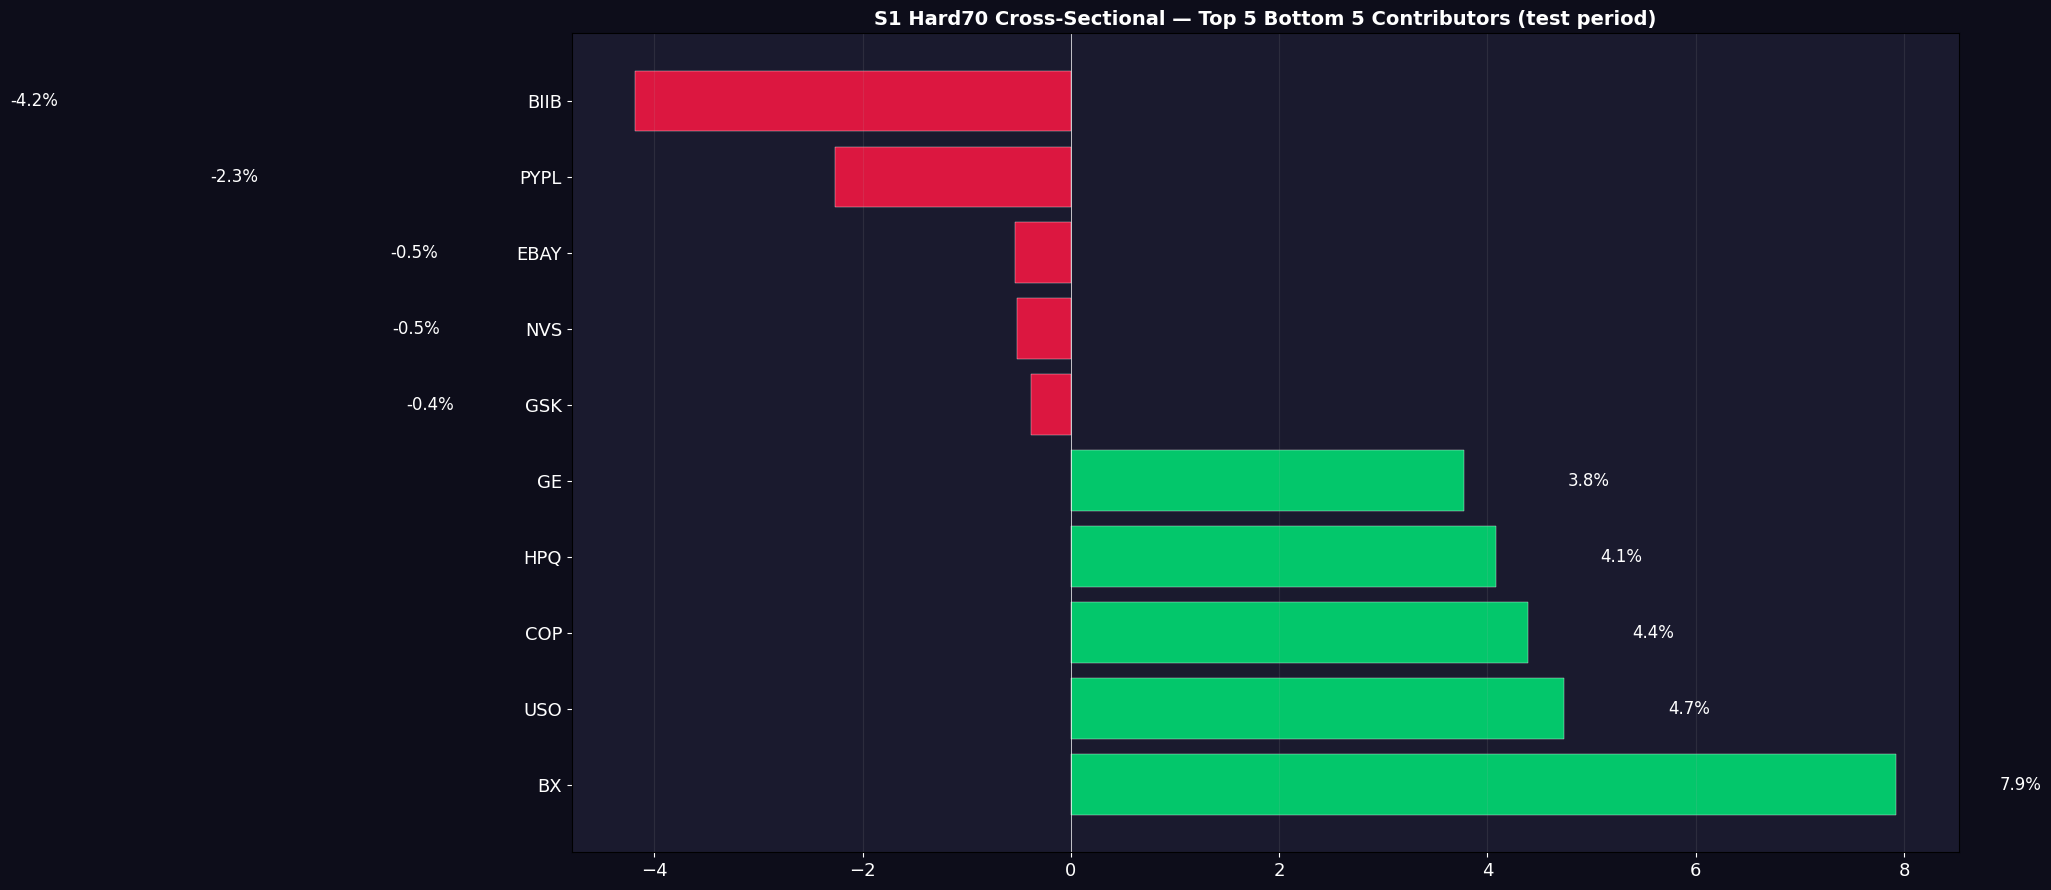

ticker
BX      0.0792
USO     0.0473
COP     0.0439
HPQ     0.0409
GE      0.0377
GSK    -0.0038
NVS    -0.0052
EBAY   -0.0054
PYPL   -0.0227
BIIB   -0.0419
dtype: float64

In [24]:
split_emb_dt = ret_df.index[split_emb]
w_test = w_text.loc[split_emb_dt:]
test_ret_df = ret_df.loc[split_emb_dt:].fillna(0.0)

ticker_ret = w_test.multiply(test_ret_df).sum(axis=0)
ticker_ret = ticker_ret.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(22, 9))
fig.patch.set_facecolor(BG)
top = ticker_ret.head(5)
bot = ticker_ret.tail(5)
combined = pd.concat([top, bot])
y_pos = np.arange(len(combined))
colors = [GREEN if v > 0 else RED for v in combined.values]
ax.barh(y_pos, combined.values * 100, color=colors, alpha=0.85, edgecolor='white', lw=0.3)
ax.set_yticks(y_pos)
ax.set_yticklabels(combined.index, color='white', fontsize=13)
ax.axvline(0, color='white', lw=0.5)
for i, v in enumerate(combined.values * 100):
    ax.text(v + (1 if v >= 0 else -6), i, f'{v:.1f}%', va='center', color='white', fontsize=12)
ax.set_title(f'S1 Hard70 Cross-Sectional — Top 5 Bottom 5 Contributors (test period)', color='white', fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)
ax.tick_params(colors='white', labelsize=13)
ax.grid(True, alpha=0.12, axis='x')
fig.tight_layout()
fig.savefig(_images / 'final_embed_ticker_contrib.png', dpi=300, facecolor=BG, edgecolor='none', bbox_inches='tight')
plt.show()

pd.concat([top, bot]).round(4)


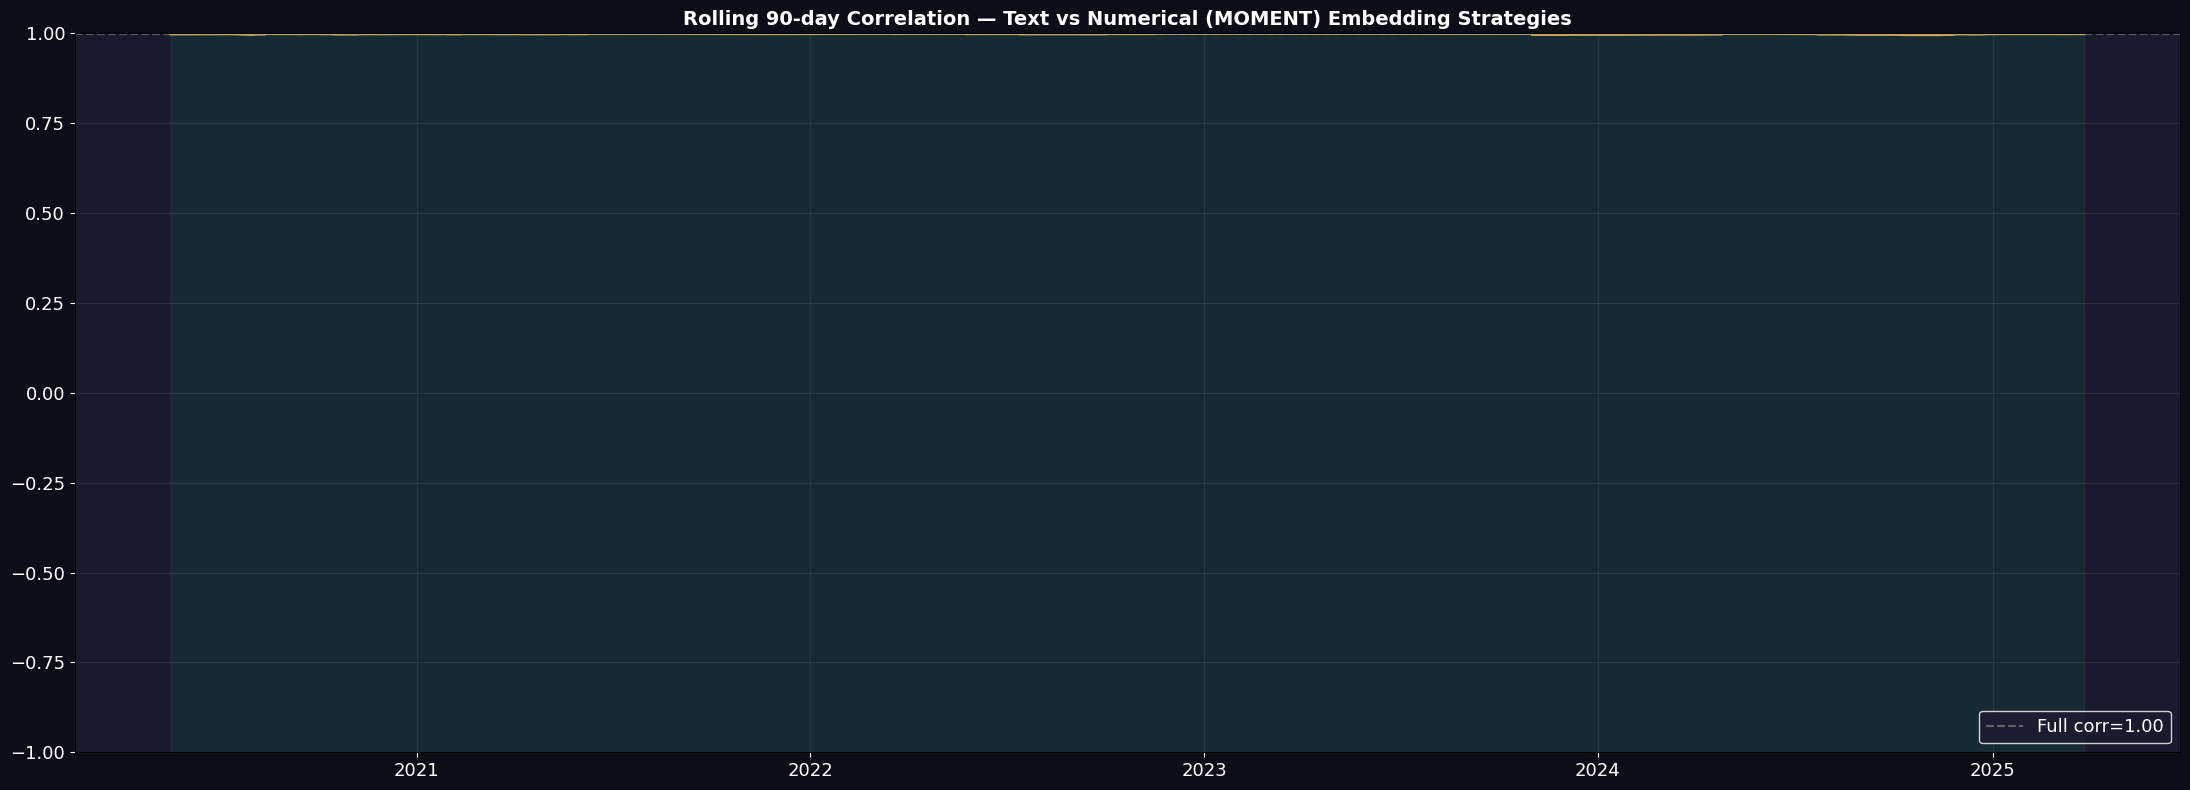

,value
count,1191.000000
mean,0.998602
std,0.000916
min,0.995773
25%,0.998220
50%,0.998778
75%,0.999252
max,0.999822


In [25]:
common_idx = sr_text.index.intersection(sr_moment.index)
strat_t = sr_text.loc[common_idx]
strat_m = sr_moment.loc[common_idx]
roll_corr = strat_t.rolling(90).corr(strat_m)

fig, ax = plt.subplots(figsize=(22, 8))
fig.patch.set_facecolor(BG)
ax.plot(roll_corr.index, roll_corr.values, color=GOLD, lw=2)
ax.axhline(strat_t.corr(strat_m), color=WHITE, ls='--', alpha=0.5, label=f'Full corr={strat_t.corr(strat_m):.2f}')
ax.fill_between(roll_corr.index, -1, roll_corr.values, where=roll_corr.values >= 0, color=GREEN, alpha=0.08)
ax.fill_between(roll_corr.index, -1, roll_corr.values, where=roll_corr.values < 0, color=RED, alpha=0.08)
ax.set_title(f'Rolling 90-day Correlation — Text vs Numerical (MOMENT) Embedding Strategies', color='white', fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)
ax.tick_params(colors='white', labelsize=13)
ax.grid(True, alpha=0.12)
ax.set_ylim(-1, 1)
ax.legend(fontsize=13, facecolor=PANEL, edgecolor='white', labelcolor='white', loc='lower right')
fig.tight_layout()
fig.savefig(_images / 'final_text_vs_moment_corr.png', dpi=300, facecolor=BG, edgecolor='none', bbox_inches='tight')
plt.show()

roll_corr.describe().to_frame('value')


In [26]:
comparison_rows = [{
    'strategy': 'Text Embedding (S1 Hard70)',
    'return_pct': r_text.metrics['total_return_pct'],
    'bh_pct':     r_text.metrics['bh_return_pct'],
    'excess_pct': r_text.metrics['excess_return_pct'],
    'sharpe':     r_text.metrics['sharpe'],
    'alpha_pct':  r_text.metrics['alpha_pct'],
    'beta':        r_text.metrics['beta'],
    'max_dd_pct': r_text.metrics['max_drawdown_pct'],
    'assets': '~50 cross-sectional',
}]

comparison_rows.append({
    'strategy': 'Numerical (MOMENT)',
    'return_pct': r_moment.metrics['total_return_pct'],
    'bh_pct':     r_moment.metrics['bh_return_pct'],
    'excess_pct': r_moment.metrics['excess_return_pct'],
    'sharpe':     r_moment.metrics['sharpe'],
    'alpha_pct':  r_moment.metrics['alpha_pct'],
    'beta':        r_moment.metrics['beta'],
    'max_dd_pct': r_moment.metrics['max_drawdown_pct'],
    'assets': '~50 cross-sectional',
})

for name, r in results.items():
    m = r.metrics
    comparison_rows.append({
        'strategy': name,
        'return_pct': m['total_return_pct'],
        'bh_pct':     m['bh_return_pct'],
        'excess_pct': m['excess_return_pct'],
        'sharpe':     m['sharpe'],
        'alpha_pct':  m['alpha_pct'],
        'beta':        m['beta'],
        'max_dd_pct': m['max_drawdown_pct'],
        'assets': '~50 cross-sectional',
    })

comp_df = pd.DataFrame(comparison_rows)
comp_df = comp_df.sort_values('excess_pct', ascending=False)
comp_df.reset_index(drop=True)


,strategy,return_pct,bh_pct,excess_pct,sharpe,alpha_pct,beta,max_dd_pct,assets
0,Text Embedding (S1 Hard70),122.386088,94.264426,28.121661,0.447266,0.914805,1.157830,-22.738696,~50 cross-sectional
1,Numerical (MOMENT),26.029083,20.974480,5.054603,0.705308,0.779134,1.166323,-14.702700,~50 cross-sectional
2,SMA 20/100,19.640393,91.335798,-71.695405,0.396911,-3.750308,0.541246,-22.888842,~50 cross-sectional
3,Mean Reversion,6.272877,91.335798,-85.062921,0.170013,3.530607,-0.095518,-22.424350,~50 cross-sectional
4,SMA 10/50,4.897566,91.335798,-86.438232,0.148385,-6.509782,0.533445,-28.484210,~50 cross-sectional
5,S1 Hard70,-13.194547,91.335798,-104.530344,-0.247588,-2.345002,-0.013619,-24.590536,~50 cross-sectional
6,Intensity Gated,-16.762862,91.335798,-108.098660,-0.310584,-3.184415,-0.014196,-29.483446,~50 cross-sectional
7,Regime Router,-29.262242,91.335798,-120.598040,-0.409950,-5.431608,-0.059835,-39.034483,~50 cross-sectional


## 7. Features — Portfólio Real

Indicadores técnicos, regimes de volatilidade e intensidade Hawkes calculados sobre a série do portfólio.

In [27]:
feat   = compute_all(df_test)
rv     = realized_volatility(df_test['close'], 20)
labels = volatility_regime_labels(df_test['close'], 3)
events = (labels.diff().abs() > 0).astype(float)
hw     = hawkes_intensity(events, alpha=0.8, beta=0.2)

pd.DataFrame({
    'feature': ['indicator columns', 'vol regimes (low/med/high %)', 'Hawkes intensity mean', 'Hawkes intensity max', 'realized vol mean'],
    'value': [len(feat.columns),
              f'{(labels==0).mean()*100:.0f}/{(labels==1).mean()*100:.0f}/{(labels==2).mean()*100:.0f}',
              f'{hw.mean():.4f}', f'{hw.max():.4f}', f'{rv.mean():.4f}']
})


,feature,value
0,indicator columns,23
1,vol regimes (low/med/high %),33/33/34
2,Hawkes intensity mean,1.7776
3,Hawkes intensity max,3.7498
4,realized vol mean,0.1489


## 8. Estrutura

```
src/backtest     engine, monte carlo, otimizador, stress test, visualizacao
src/strategy     8 estrategias deterministicas + modelos treinados com embeddings
src/features     23 indicadores tecnicos + volatilidade + Hawkes

notebooks        EDA, embeddings, volatilidade, backtests, fusao, portfolio
scripts          scrapers (B3, LSE, Google News RSS)
latex            proposta IC + resultados compilados
images           plots dark-mode, dpi=300
```

21 métricas por backtest. Sempre comparando contra buy & hold com decomposição alpha/beta.